# 🎵 Analiza Glasbenih Trendov na Platformi Spotify

## Raziskovalni Problem

**Kateri zvočni in žanrski vzorci opredeljujejo glasbene trende na Spotifyju in kako so ti vzorci povezani s priljubljenostjo skladb?**

### Raziskovalna Vprašanja

1. Katere zvočne značilnosti najbolj opisujejo sodobne glasbene trende na Spotifyju?
2. Kako so zvočne značilnosti med seboj povezane?
3. Ali obstajajo značilni tipi skladb (glasbeni profili), ki jih lahko identificiramo s pomočjo podatkovne analize?
4. Kako se posamezni glasbeni profili razlikujejo glede na priljubljenost skladb?
5. Ali lahko na podlagi zvočnih značilnosti napovemo priljubljenost skladb?
6. **Kako se slovenski trg primerja z globalnimi glasbenimi trendi?**

---

## Metodologija in Podatkovni Viri

### ⚠️ Kritična Metodološka Opomba

**Od novembra 2024 Spotify Web API ne omogoča več dostopa do `audio-features` endpointa** za standardne aplikacije. To NI napaka v kodi, ampak omejitev na strani ponudnika.

Zato ta analiza uporablja **dvotirni pristop**:

| Vir | Tip | Vsebina | Uporaba v analizi |
|-----|-----|---------|-------------------|
| **Kaggle CSV** | Statični | 114.000+ skladb z audio features | EDA, statistika, ML, clustering |
| **Spotify Web API** | Dinamični | Metapodatki (popularity, artist info) | Kontekst in primerjava trgov |

### Vloga Kaggle CSV Podatkov (GLAVNI VIR)

CSV dataseti vsebujejo **vse zvočne značilnosti** (audio features):
- `danceability`, `energy`, `valence`, `tempo`, `loudness`
- `speechiness`, `acousticness`, `instrumentalness`, `liveness`

Ti podatki so:
- ✅ Reproducibilni in konsistentni
- ✅ Primerni za statistično analizo in ML
- ✅ Neodvisni od API omejitev

### Vloga Spotify Web API (DOPOLNILNI VIR)

API uporabljamo **IZKLJUČNO** za:
1. **Identifikacijo trenutnih trendov** - Top 50 playliste po državah
2. **Pridobivanje metapodatkov** - track popularity, artist genres, followers
3. **Kontekstualno obogatitev** - primerjava med trgi

API **NE uporabljamo** za:
- ❌ Pridobivanje audio features (endpoint ni dostopen)
- ❌ Zgodovinske podatke (API vrača samo snapshot)

### Zvočne značilnosti (Audio Features)

| Atribut | Opis | Razpon | Vir |
|---------|------|--------|-----|
| `danceability` | Primernost za ples | 0.0 - 1.0 | CSV |
| `energy` | Intenzivnost in aktivnost | 0.0 - 1.0 | CSV |
| `loudness` | Glasnost v dB | -60 - 0 | CSV |
| `speechiness` | Prisotnost govora | 0.0 - 1.0 | CSV |
| `acousticness` | Akustična narava | 0.0 - 1.0 | CSV |
| `instrumentalness` | Instrumentalna narava | 0.0 - 1.0 | CSV |
| `liveness` | Prisotnost občinstva | 0.0 - 1.0 | CSV |
| `valence` | Pozitivnost/veselost | 0.0 - 1.0 | CSV |
| `tempo` | BPM | 0 - 250 | CSV |
| `popularity` | Priljubljenost (snapshot) | 0 - 100 | CSV / API |

### Analitična Struktura

| Faza | Metoda | Podatkovni vir |
|------|--------|----------------|
| EDA | Histogrami, violin ploti, radar charts | Kaggle CSV |
| Korelacije | Pearson, Spearman | Kaggle CSV |
| Statistika | T-test, ANOVA | Kaggle CSV |
| Clustering | K-Means, PCA | Kaggle CSV |
| Regresija | Random Forest, Gradient Boosting | Kaggle CSV |
| Primerjava držav | API playliste + CSV audio features | API + CSV |

### ⚠️ Pomembne Omejitve
- **Spotify 'popularity' je snapshot vrednost** - predstavlja trenutno priljubljenost, NE zgodovinsko
- **API omejitve** - audio features niso dostopne, uporabljamo CSV podatke
- **Primerjava držav** - identificiramo trende iz API, analiziramo z CSV podatki

## 1. Uvoz Potrebnih Knjižnic

Najprej uvozimo vse potrebne knjižnice za analizo podatkov, vizualizacijo, statistične teste in strojno učenje.

In [1]:
# Osnovne knjižnice
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Vizualizacija
import matplotlib.pyplot as plt
import seaborn as sns

# Statistična analiza
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway

# Strojno učenje
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.feature_selection import SelectKBest, f_classif

# Spotify API
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Nastavitve vizualizacije
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✅ Vse knjižnice uspešno uvožene!")

✅ Vse knjižnice uspešno uvožene!


## 2. Nalaganje in Integracija Podatkov

### Podatkovni viri:
1. **dataset.csv** - Kaggle Spotify dataset z 114.000+ skladbami
2. **SpotifyFeatures.csv** - Dodatni Spotify features dataset
3. **Spotify Web API** - Za pridobivanje dodatnih metapodatkov

### Zvočne značilnosti (Audio Features)

| Atribut | Opis | Razpon |
|---------|------|--------|
| `danceability` | Primernost za ples | 0.0 - 1.0 |
| `energy` | Intenzivnost in aktivnost | 0.0 - 1.0 |
| `loudness` | Glasnost v dB | -60 - 0 |
| `speechiness` | Prisotnost govora | 0.0 - 1.0 |
| `acousticness` | Akustična narava | 0.0 - 1.0 |
| `instrumentalness` | Instrumentalna narava | 0.0 - 1.0 |
| `liveness` | Prisotnost občinstva | 0.0 - 1.0 |
| `valence` | Pozitivnost/veselost | 0.0 - 1.0 |
| `tempo` | BPM | 0 - 250 |
| `popularity` | Priljubljenost | 0 - 100 |

In [2]:
# Nalaganje glavnega dataseta
df_main = pd.read_csv('../data/dataset.csv')

print(f"📊 Glavni dataset (dataset.csv):")
print(f"   Število skladb: {len(df_main):,}")
print(f"   Število stolpcev: {df_main.shape[1]}")
print(f"   Žanri: {df_main['track_genre'].nunique()}")

# Nalaganje dodatnega dataseta
df_features = pd.read_csv('../data/SpotifyFeatures.csv')

print(f"\n📊 Dodatni dataset (SpotifyFeatures.csv):")
print(f"   Število skladb: {len(df_features):,}")
print(f"   Število stolpcev: {df_features.shape[1]}")

# Prikaz strukture glavnega dataseta
print("\n📋 Stolpci v glavnem datasetu:")
print(df_main.columns.tolist())

df_main.head()

📊 Glavni dataset (dataset.csv):
   Število skladb: 114,000
   Število stolpcev: 21
   Žanri: 114

📊 Dodatni dataset (SpotifyFeatures.csv):
   Število skladb: 232,725
   Število stolpcev: 18

📋 Stolpci v glavnem datasetu:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2.1 Spotify Web API - Konfiguracija

### Dovoljena uporaba API-ja:
- ✅ Pridobivanje **track metadata** (ime, izvajalec, popularity)
- ✅ Pridobivanje **artist info** (followers, genres, popularity)
- ✅ Pridobivanje **playlist tracks** (Top 50 po državah)

### Prepovedana uporaba (endpoint ni dostopen):
- ❌ `audio-features` endpoint (ukinjen nov 2024)
- ❌ `audio-analysis` endpoint

**Vse zvočne značilnosti (danceability, energy, valence, itd.) pridobimo iz Kaggle CSV datotek.**

In [3]:
# =============================================================================
# SPOTIFY API KONFIGURACIJA
# =============================================================================
# OPOMBA: API se uporablja SAMO za metapodatke in playliste,
#         NE za audio features (endpoint ni dostopen od nov 2024)
# =============================================================================

import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Spotify API credentials
SPOTIFY_CLIENT_ID = "9ec80be4c678400bb562c2b2918e87db"
SPOTIFY_CLIENT_SECRET = "dfeead37e4cb41e8b8dd9d607dbf33b0"

# Inicializacija API povezave
sp = None

try:
    client_credentials_manager = SpotifyClientCredentials(
        client_id=SPOTIFY_CLIENT_ID,
        client_secret=SPOTIFY_CLIENT_SECRET
    )
    sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)
    
    # Test API - pridobi osnovne metapodatke o skladbi (NE audio features!)
    test_track = sp.track("4cOdK2wGLETKBW3PvgPWqT")
    
    print("✅ Spotify API povezava uspešna!")
    print(f"   Test skladba: {test_track['name']} - {test_track['artists'][0]['name']}")
    print(f"   Popularity (API): {test_track['popularity']}")
    print("\n📋 API se bo uporabljal za:")
    print("   • Pridobivanje Top 50 playlist po državah")
    print("   • Metapodatke o skladbah (popularity, artist info)")
    print("\n⚠️  Audio features bodo pridobljene iz CSV datasetov!")

except Exception as e:
    sp = None
    print(f"⚠️ Spotify API ni povezan: {e}")
    print("   Analiza bo nadaljevana samo s CSV podatki.")
    print("   Primerjava držav bo izvedena s simuliranimi podatki.")

✅ Spotify API povezava uspešna!
   Test skladba: Never Gonna Give You Up - Rick Astley
   Popularity (API): 6

📋 API se bo uporabljal za:
   • Pridobivanje Top 50 playlist po državah
   • Metapodatke o skladbah (popularity, artist info)

⚠️  Audio features bodo pridobljene iz CSV datasetov!


In [4]:
# =============================================================================
# HELPER FUNKCIJE ZA SPOTIFY API (brez audio-features!)
# =============================================================================

def get_spotify_artist_info(sp, artist_name, limit=1):
    """
    Pridobi informacije o izvajalcu iz Spotify API.
    Vrne: followers, genres, popularity
    
    OPOMBA: Ta funkcija NE pridobiva audio features!
    """
    if sp is None:
        return None
    try:
        results = sp.search(q=f'artist:{artist_name}', type='artist', limit=limit)
        if results['artists']['items']:
            artist = results['artists']['items'][0]
            return {
                'spotify_followers': artist['followers']['total'],
                'spotify_genres': artist['genres'],
                'spotify_popularity': artist['popularity']
            }
    except Exception as e:
        pass
    return None

def get_playlist_tracks_metadata(sp, playlist_id, country_name):
    """
    Pridobi metapodatke o skladbah iz playliste (NE audio features!).
    Vrne: track_id, track_name, artist, popularity, country
    
    Audio features je potrebno pridobiti iz CSV datasetov!
    """
    if sp is None:
        return None
    
    try:
        results = sp.playlist_tracks(playlist_id, limit=50)
        tracks = results['items']
        
        data = []
        for item in tracks:
            track = item['track']
            if track and track['id']:
                data.append({
                    'track_id': track['id'],
                    'track_name': track['name'],
                    'artist': track['artists'][0]['name'] if track['artists'] else 'Unknown',
                    'api_popularity': track['popularity'],  # Označeno kot API podatek
                    'country': country_name
                })
        
        return pd.DataFrame(data)
    
    except Exception as e:
        print(f"   ⚠️ Napaka pri {country_name}: {e}")
        return None

# Potrditev, da NE uporabljamo audio_features endpoint
print("✅ Helper funkcije naložene")
print("   • get_spotify_artist_info() - pridobi artist metadata")
print("   • get_playlist_tracks_metadata() - pridobi track metadata iz playlist")
print("\n⚠️  Audio features se NE pridobivajo iz API-ja!")
print("   Vir audio features: Kaggle CSV dataseti")

✅ Helper funkcije naložene
   • get_spotify_artist_info() - pridobi artist metadata
   • get_playlist_tracks_metadata() - pridobi track metadata iz playlist

⚠️  Audio features se NE pridobivajo iz API-ja!
   Vir audio features: Kaggle CSV dataseti


In [5]:
# Uporabimo glavni dataset za analizo
df = df_main.copy()

# Preimenovanje stolpcev za konsistentnost
df = df.rename(columns={'track_genre': 'genre'})

# Definicija zvočnih značilnosti za analizo
AUDIO_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

AUDIO_FEATURES_NORMALIZED = ['danceability', 'energy', 'speechiness', 
                             'acousticness', 'instrumentalness', 'liveness', 'valence']

# Preverjanje manjkajočih vrednosti
missing_stats = pd.DataFrame({
    'missing_danceability': [df['danceability'].isna().sum()],
    'missing_energy': [df['energy'].isna().sum()],
    'missing_popularity': [df['popularity'].isna().sum()],
    'missing_genre': [df['genre'].isna().sum()]
})

print("🔍 Manjkajoče vrednosti:")
print(missing_stats.T)

# Čiščenje podatkov
initial_count = len(df)
df = df.dropna(subset=AUDIO_FEATURES + ['popularity'])
df = df.drop_duplicates(subset=['track_id'])

print(f"\n✅ Čiščenje podatkov:")
print(f"   Začetno število: {initial_count:,}")
print(f"   Končno število: {len(df):,}")
print(f"   Odstranjeno: {initial_count - len(df):,} ({(initial_count - len(df))/initial_count*100:.1f}%)")

🔍 Manjkajoče vrednosti:
                      0
missing_danceability  0
missing_energy        0
missing_popularity    0
missing_genre         0

✅ Čiščenje podatkov:
   Začetno število: 114,000
   Končno število: 89,741
   Odstranjeno: 24,259 (21.3%)


## 3. Eksplorativna Analiza Podatkov (EDA)

**📊 Podatkovni vir: Kaggle CSV dataset (114.000+ skladb)**

### 3.1 Univariatna analiza

**Namen:** Razumeti porazdelitve posameznih zvočnih značilnosti.

**Vprašanja:**
- Kakšne so tipične vrednosti za vsako značilnost?
- Ali so podatki normalno porazdeljeni?
- Kje se nahajajo osamelci (outliers)?

**Zakaj ta vizualizacija ni redundantna:** Histogrami prikazujejo celotne porazdelitve, kar je osnova za vse nadaljnje analize.

In [6]:
# Izpeljani atributi
print("🔧 Ustvarjanje izpeljanih atributov...")

# 1. Kategorija priljubljenosti
df['popularity_category'] = pd.cut(df['popularity'], 
                                   bins=[0, 33, 66, 100], 
                                   labels=['Nizka', 'Srednja', 'Visoka'])

# 2. Normalizirana glasnost (0-1)
df['loudness_normalized'] = (df['loudness'] - df['loudness'].min()) / (df['loudness'].max() - df['loudness'].min())

# 3. Indeks razpoloženja (mood score)
df['mood_score'] = (df['valence'] + df['energy'] + df['danceability']) / 3

# 4. Indeks primernosti za klube
tempo_normalized = (df['tempo'].clip(60, 180) - 60) / 120
df['club_score'] = (df['danceability'] + df['energy'] + tempo_normalized) / 3

# 5. Akustični indeks
df['acoustic_score'] = df['acousticness'] * (1 - df['energy'])

# Statistike po žanrih
genre_stats = df.groupby('genre').agg({
    'track_id': 'count',
    'popularity': 'mean',
    'danceability': 'mean',
    'energy': 'mean',
    'valence': 'mean'
}).round({'popularity': 2, 'danceability': 3, 'energy': 3, 'valence': 3})

genre_stats = genre_stats.rename(columns={'track_id': 'count'})
genre_stats = genre_stats.sort_values('count', ascending=False).head(15).reset_index()
genre_stats.columns = ['genre', 'count', 'avg_popularity', 'avg_danceability', 'avg_energy', 'avg_valence']

print("\n📊 Top 15 žanrov po številu skladb:")
print(genre_stats.to_string(index=False))

🔧 Ustvarjanje izpeljanih atributov...

📊 Top 15 žanrov po številu skladb:
        genre  count  avg_popularity  avg_danceability  avg_energy  avg_valence
     acoustic   1000           42.48             0.550       0.435        0.424
     afrobeat    999           24.41             0.669       0.703        0.698
     alt-rock    999           33.90             0.535       0.754        0.518
      ambient    999           44.21             0.368       0.237        0.167
     cantopop    999           34.75             0.548       0.462        0.393
        tango    999           19.87             0.538       0.373        0.584
chicago-house    998           12.33             0.766       0.733        0.587
        forro    998           41.83             0.650       0.790        0.760
    bluegrass    998           25.68             0.535       0.530        0.635
        study    998           26.13             0.685       0.411        0.403
       disney    998           27.49          

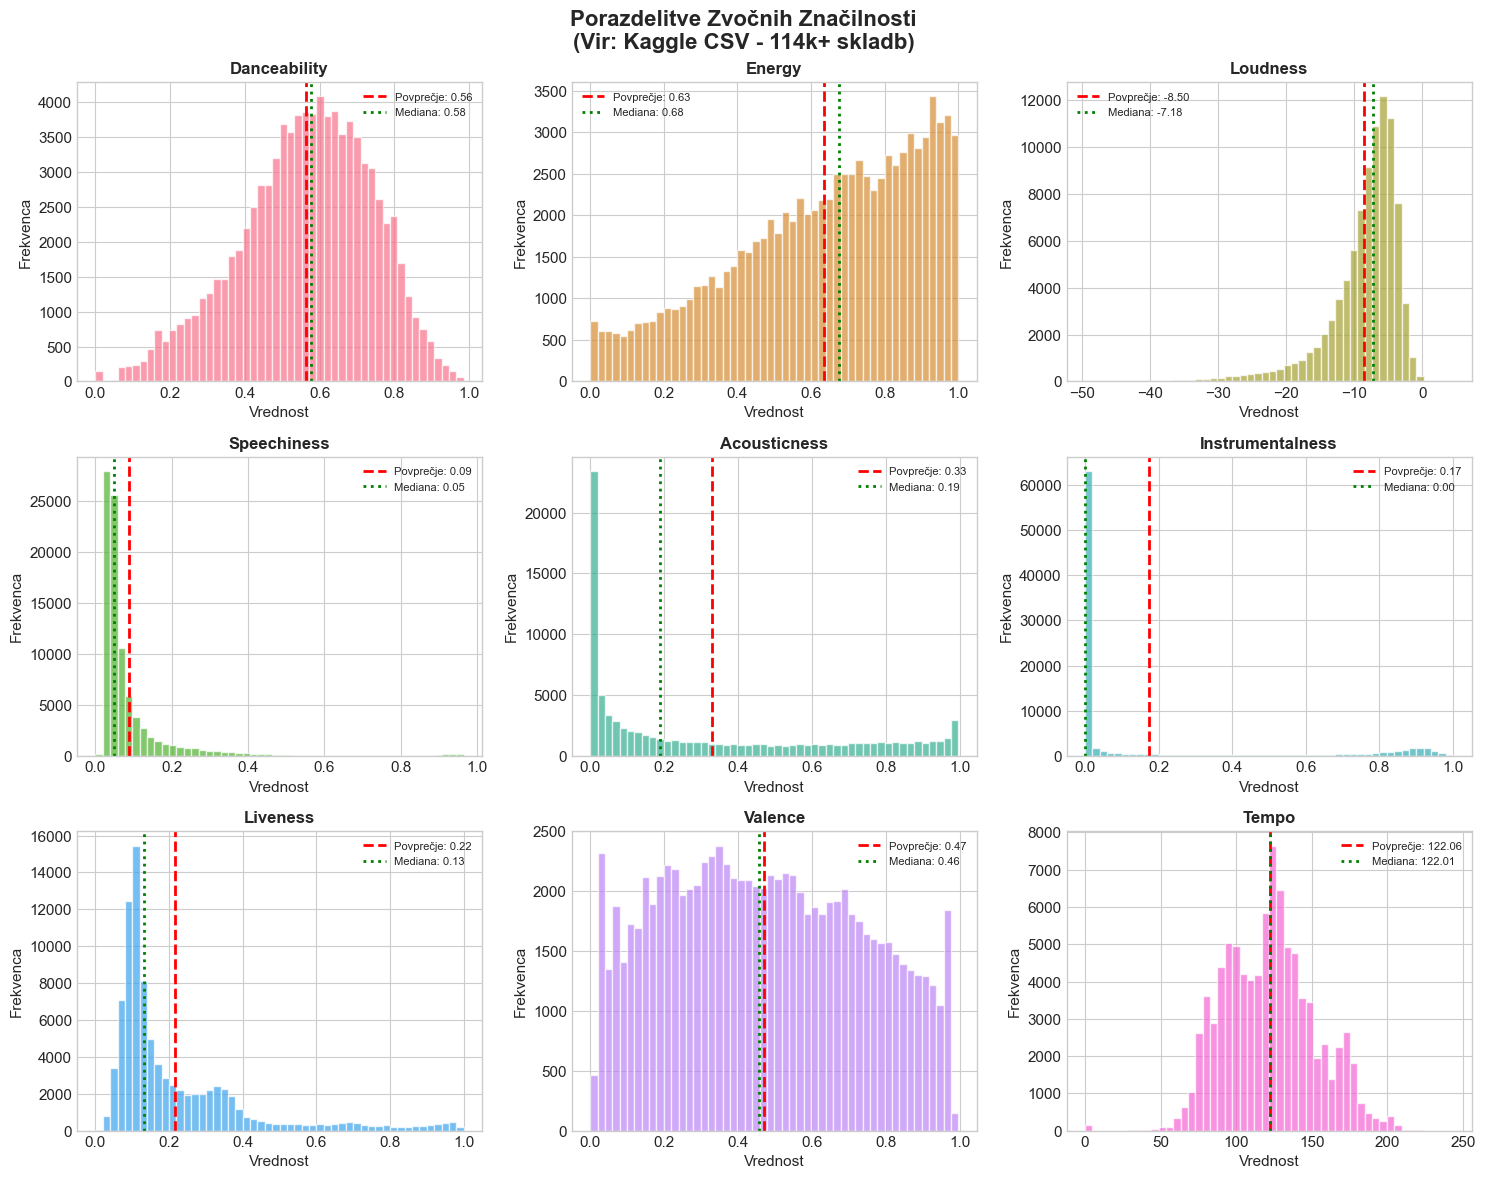

📊 Vizualizacija: Porazdelitve zvočnih značilnosti
   Vir podatkov: Kaggle CSV dataset
   Namen: Univariatna analiza - razumevanje porazdelitev
✅ Slika shranjena: outputs/01_distributions.png


In [7]:
# =============================================================================
# VIZUALIZACIJA: Porazdelitve zvočnih značilnosti - HISTOGRAMI
# =============================================================================
# Vir: Kaggle CSV dataset
# Namen: Razumevanje porazdelitev posameznih audio features
# Vprašanje: Kakšne so tipične vrednosti za vsako značilnost?
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Porazdelitve Zvočnih Značilnosti\n(Vir: Kaggle CSV - 114k+ skladb)', 
             fontsize=16, fontweight='bold')

colors = sns.color_palette("husl", 9)

for idx, (feature, ax) in enumerate(zip(AUDIO_FEATURES, axes.flatten())):
    ax.hist(df[feature], bins=50, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Povprečje: {df[feature].mean():.2f}')
    ax.axvline(df[feature].median(), color='green', linestyle=':', linewidth=2, 
               label=f'Mediana: {df[feature].median():.2f}')
    ax.set_title(feature.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Vrednost')
    ax.set_ylabel('Frekvenca')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Vizualizacija: Porazdelitve zvočnih značilnosti")
print("   Vir podatkov: Kaggle CSV dataset")
print("   Namen: Univariatna analiza - razumevanje porazdelitev")
print("✅ Slika shranjena: outputs/01_distributions.png")

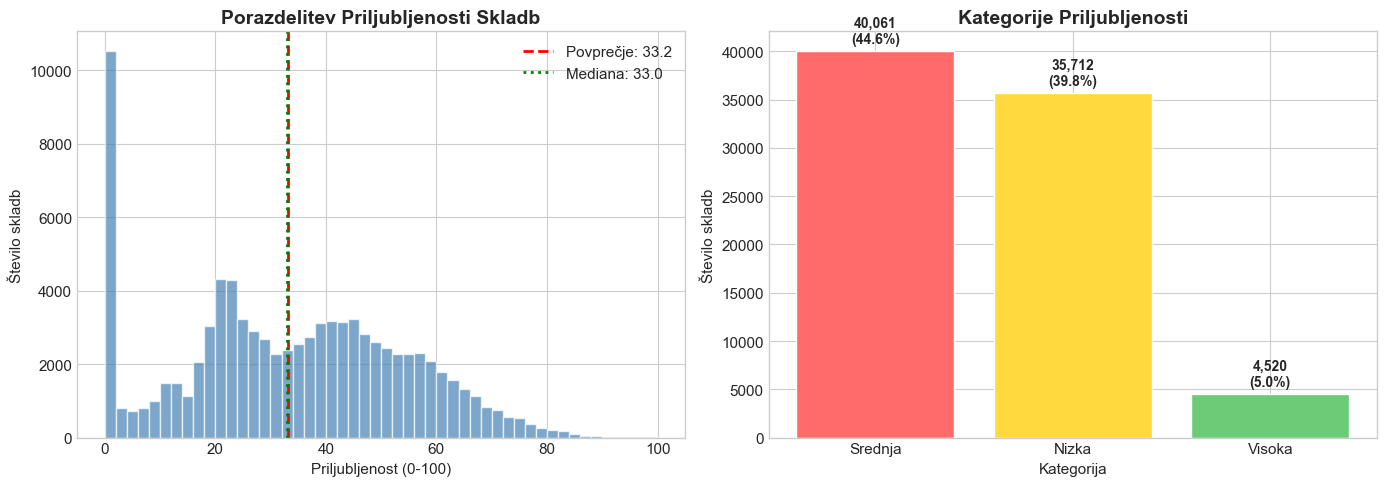

In [8]:
# Porazdelitev priljubljenosti in kategorij
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram priljubljenosti
axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Povprečje: {df["popularity"].mean():.1f}')
axes[0].axvline(df['popularity'].median(), color='green', linestyle=':', linewidth=2,
                label=f'Mediana: {df["popularity"].median():.1f}')
axes[0].set_title('Porazdelitev Priljubljenosti Skladb', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Priljubljenost (0-100)')
axes[0].set_ylabel('Število skladb')
axes[0].legend()

# Stolpični diagram kategorij priljubljenosti
pop_counts = df['popularity_category'].value_counts()
bars = axes[1].bar(pop_counts.index, pop_counts.values, color=['#ff6b6b', '#ffd93d', '#6bcb77'], edgecolor='white')
axes[1].set_title('Kategorije Priljubljenosti', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kategorija')
axes[1].set_ylabel('Število skladb')

for bar, count in zip(bars, pop_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                 f'{count:,}\n({count/len(df)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_popularity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

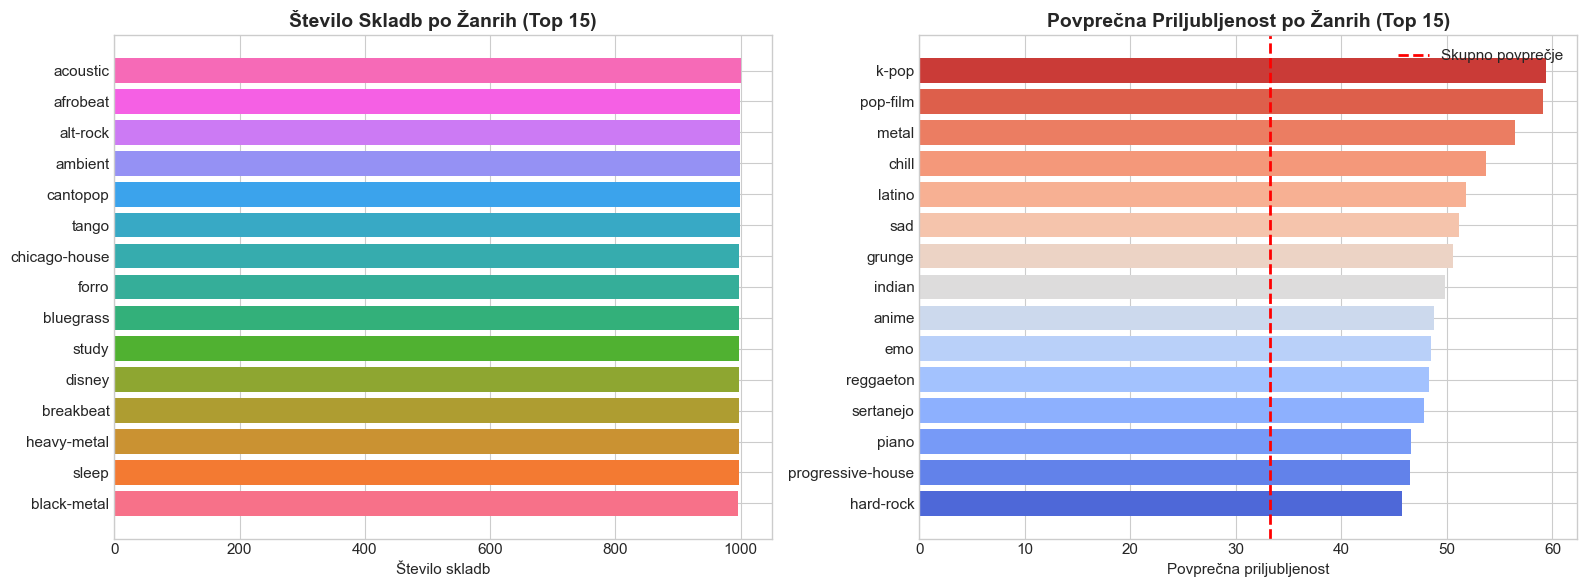

✅ Analiza žanrov:
            genre  total_tracks  avg_popularity  avg_danceability  avg_energy
            k-pop           917           59.36             0.642       0.683
         pop-film           815           59.10             0.591       0.600
            metal           232           56.42             0.481       0.841
            chill           972           53.74             0.666       0.430
           latino           398           51.79             0.755       0.712
              sad           564           51.11             0.702       0.479
           grunge           862           50.59             0.455       0.805
           indian           733           49.77             0.586       0.555
            anime           995           48.78             0.538       0.674
              emo           932           48.50             0.601       0.668
        reggaeton            74           48.27             0.743       0.737
        sertanejo           826           47.8

In [9]:
# Analiza žanrov
genre_analysis = df.groupby('genre').agg({
    'track_id': 'count',
    'popularity': 'mean',
    'danceability': 'mean',
    'energy': 'mean'
}).round({'popularity': 2, 'danceability': 3, 'energy': 3})

genre_analysis = genre_analysis.rename(columns={'track_id': 'total_tracks'})
genre_analysis = genre_analysis.sort_values('popularity', ascending=False).head(20).reset_index()
genre_analysis.columns = ['genre', 'total_tracks', 'avg_popularity', 'avg_danceability', 'avg_energy']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 žanrov po številu skladb
top_genres = df['genre'].value_counts().head(15)
bars1 = axes[0].barh(top_genres.index[::-1], top_genres.values[::-1], color=sns.color_palette("husl", 15))
axes[0].set_title('Število Skladb po Žanrih (Top 15)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Število skladb')

# Top 15 žanrov po priljubljenosti
top_pop_genres = genre_analysis.head(15)
bars2 = axes[1].barh(top_pop_genres['genre'][::-1], top_pop_genres['avg_popularity'][::-1], 
                     color=sns.color_palette("coolwarm", 15))
axes[1].set_title('Povprečna Priljubljenost po Žanrih (Top 15)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Povprečna priljubljenost')
axes[1].axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2, label='Skupno povprečje')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Analiza žanrov:")
print(genre_analysis.to_string(index=False))

### 3.2 Bivariatna in Multivariatna Analiza

**📊 Podatkovni vir: Kaggle CSV dataset**

**Namen:** Raziskovanje odnosov med dvema in več spremenljivkami.

**Vprašanja:**
- Kako so zvočne značilnosti povezane s priljubljenostjo?
- Kateri žanri imajo podobne zvočne profile?
- Ali obstajajo skupine skladb z značilnimi vzorci?

**Zakaj te vizualizacije niso redundantne:**
- Scatter ploti: odnos posamezne značilnosti s priljubljenostjo
- Radar chart: multivariatna primerjava žanrov
- Violin ploti: porazdelitev po kategorijah priljubljenosti

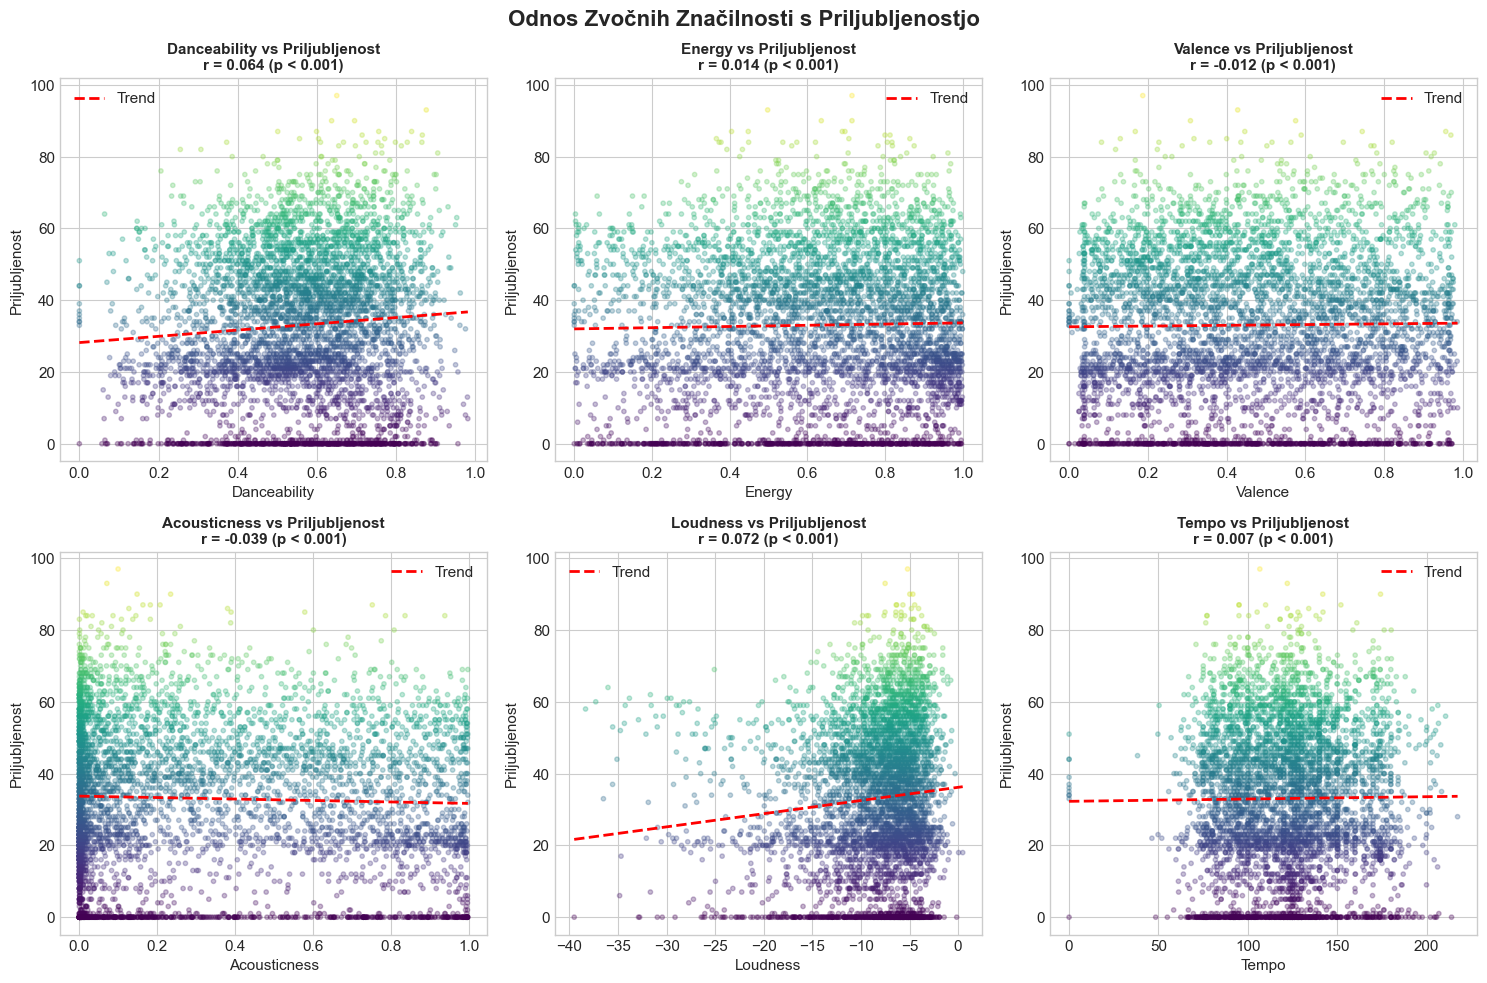

In [10]:
# Raztreseni diagrami - zvočne značilnosti vs priljubljenost
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Odnos Zvočnih Značilnosti s Priljubljenostjo', fontsize=16, fontweight='bold')

key_features = ['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo']

for idx, (feature, ax) in enumerate(zip(key_features, axes.flatten())):
    # Vzorčenje za hitrejše risanje
    sample = df.sample(min(5000, len(df)), random_state=42)
    
    scatter = ax.scatter(sample[feature], sample['popularity'], alpha=0.3, 
                        c=sample['popularity'], cmap='viridis', s=10)
    
    # Trendna črta
    z = np.polyfit(sample[feature], sample['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[feature].min(), sample[feature].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend')
    
    # Korelacija
    corr, pval = pearsonr(df[feature], df['popularity'])
    ax.set_title(f'{feature.capitalize()} vs Priljubljenost\nr = {corr:.3f} (p < 0.001)', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Priljubljenost')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/04_scatter_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

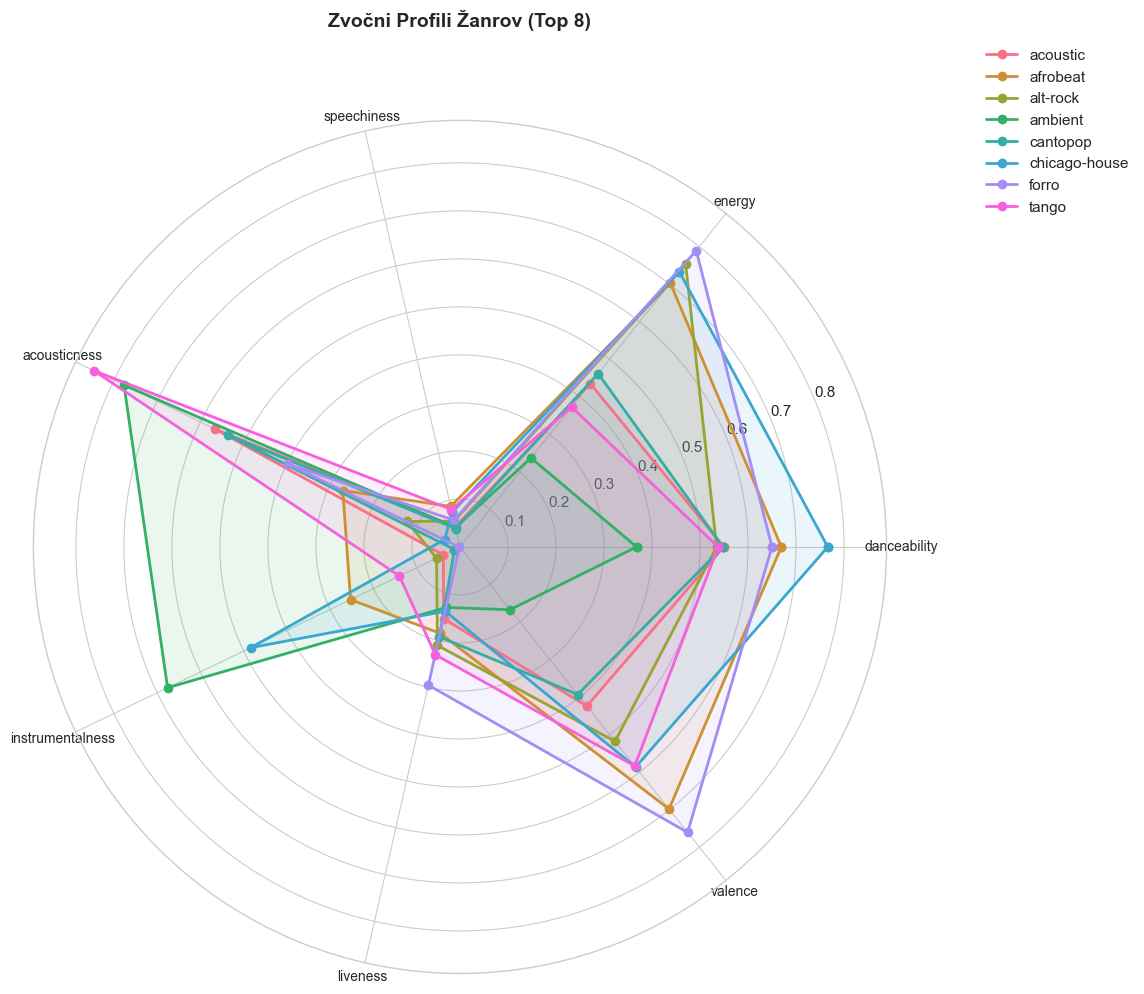

In [11]:
# Radar chart - zvočni profili top žanrov
from math import pi

# Izberemo top 8 žanrov po številu skladb
top_8_genres = df['genre'].value_counts().head(8).index.tolist()
genre_profiles = df[df['genre'].isin(top_8_genres)].groupby('genre')[AUDIO_FEATURES_NORMALIZED].mean()

# Priprava za radar chart
categories = AUDIO_FEATURES_NORMALIZED
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))
colors = sns.color_palette("husl", len(genre_profiles))

for idx, (genre, row) in enumerate(genre_profiles.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=genre, color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_title('Zvočni Profili Žanrov (Top 8)', fontsize=14, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../outputs/05_radar_genres.png', dpi=150, bbox_inches='tight')
plt.show()

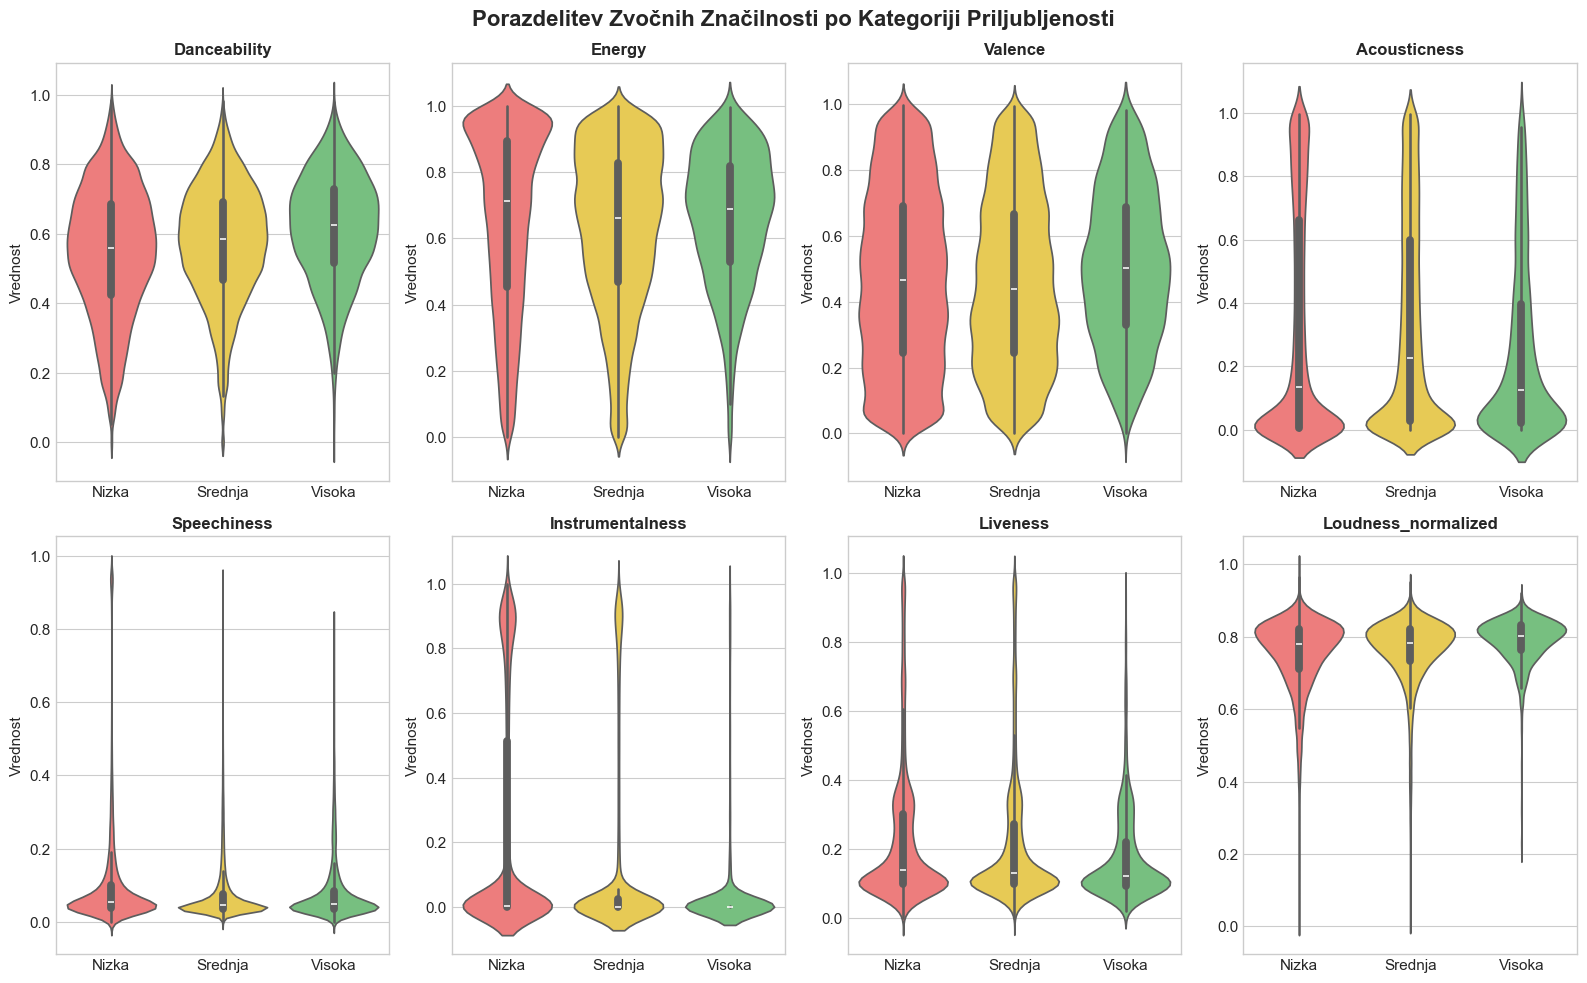

In [12]:
# Violin ploti - primerjava značilnosti po kategorijah priljubljenosti
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Porazdelitev Zvočnih Značilnosti po Kategoriji Priljubljenosti', fontsize=16, fontweight='bold')

features_to_plot = ['danceability', 'energy', 'valence', 'acousticness', 
                    'speechiness', 'instrumentalness', 'liveness', 'loudness_normalized']

palette = {'Nizka': '#ff6b6b', 'Srednja': '#ffd93d', 'Visoka': '#6bcb77'}

for idx, (feature, ax) in enumerate(zip(features_to_plot, axes.flatten())):
    sns.violinplot(data=df, x='popularity_category', y=feature, ax=ax, 
                   palette=palette, order=['Nizka', 'Srednja', 'Visoka'])
    ax.set_title(feature.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Vrednost')

plt.tight_layout()
plt.savefig('../outputs/06_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
## 4. Korelacijska Analiza

##Izračunamo Pearsonove in Spearmanove korelacijske koeficiente med zvočnimi značilnostmi in priljubljenostjo.

### Interpretacija korelacij:
# - **r > 0.7**: Močna pozitivna korelacija
# - **0.3 < r < 0.7**: Zmerna pozitivna korelacija
# - **-0.3 < r < 0.3**: Šibka/zanemarljiva korelacija
# - **r < -0.3**: Zmerna negativna korelacija

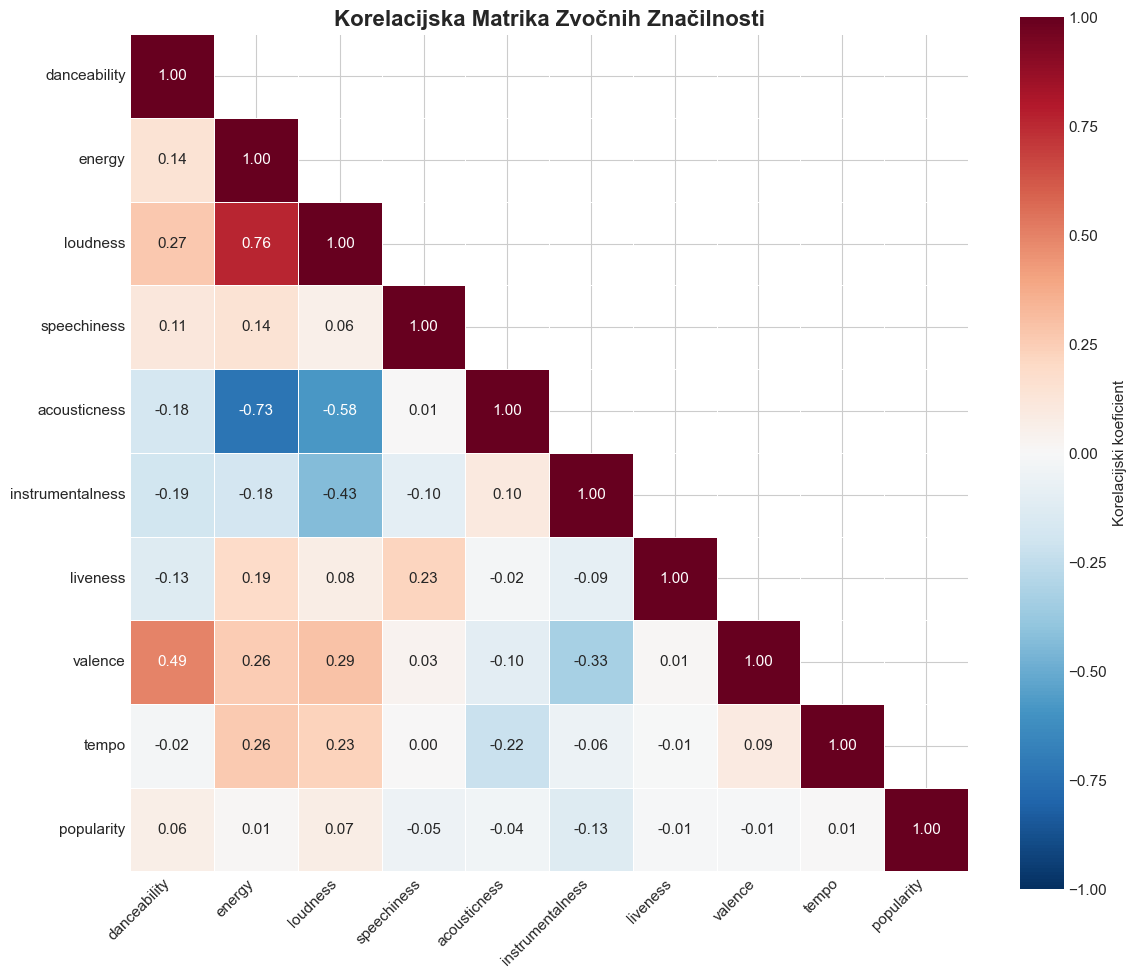

In [14]:
# Korelacijska matrika
correlation_features = AUDIO_FEATURES + ['popularity']
corr_matrix = df[correlation_features].corr()

# Toplotna karta korelacij
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Korelacijski koeficient'}, ax=ax)

ax.set_title('Korelacijska Matrika Zvočnih Značilnosti', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

KORELACIJE ZVOČNIH ZNAČILNOSTI S PRILJUBLJENOSTJO
      Značilnost  Pearson r     Pearson p  Spearman ρ Značilno
instrumentalness    -0.1275 1.294452e-321     -0.1244        ✓
        loudness     0.0717 1.584573e-102      0.0672        ✓
    danceability     0.0643  8.532516e-83      0.0553        ✓
     speechiness    -0.0471  3.218396e-45     -0.0671        ✓
    acousticness    -0.0388  2.536697e-31      0.0102        ✓
        liveness    -0.0138  3.363819e-05     -0.0114        ✓
          energy     0.0137  3.909797e-05     -0.0157        ✓
         valence    -0.0115  5.546264e-04     -0.0107        ✓
           tempo     0.0073  2.941107e-02      0.0083        ✓


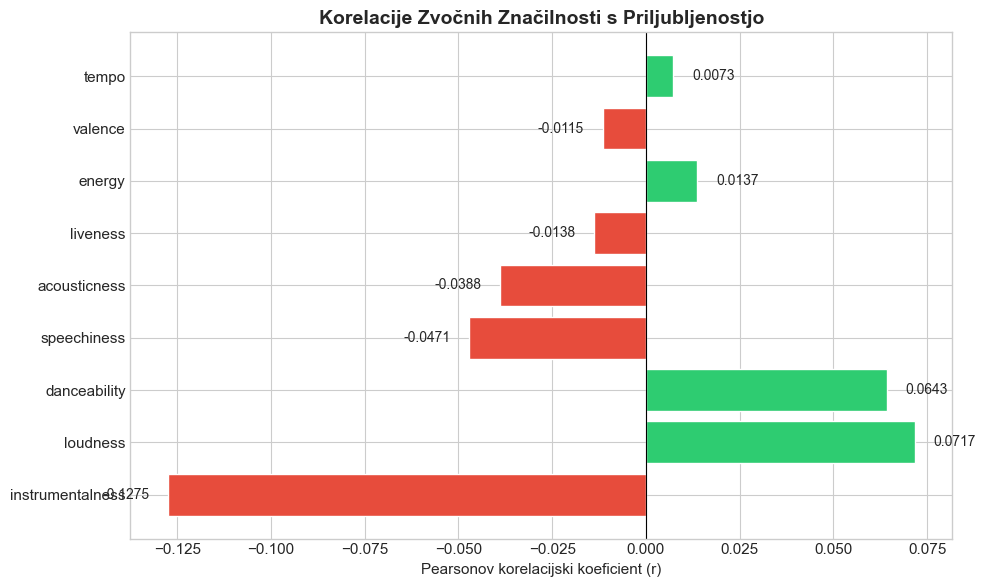

In [15]:
# Podrobna korelacijska analiza s priljubljenostjo
print("=" * 70)
print("KORELACIJE ZVOČNIH ZNAČILNOSTI S PRILJUBLJENOSTJO")
print("=" * 70)

popularity_correlations = []

for feature in AUDIO_FEATURES:
    corr, pval = pearsonr(df[feature], df['popularity'])
    spearman_corr, spearman_pval = spearmanr(df[feature], df['popularity'])
    
    popularity_correlations.append({
        'Značilnost': feature,
        'Pearson r': round(corr, 4),
        'Pearson p': pval,
        'Spearman ρ': round(spearman_corr, 4),
        'Značilno': '✓' if pval < 0.05 else '✗'
    })

corr_df = pd.DataFrame(popularity_correlations)
corr_df = corr_df.sort_values('Pearson r', key=abs, ascending=False)
print(corr_df.to_string(index=False))

# Vizualizacija
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_df['Pearson r']]
bars = ax.barh(corr_df['Značilnost'], corr_df['Pearson r'], color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearsonov korelacijski koeficient (r)')
ax.set_title('Korelacije Zvočnih Značilnosti s Priljubljenostjo', fontsize=14, fontweight='bold')

for bar, val in zip(bars, corr_df['Pearson r']):
    width = bar.get_width()
    ax.text(width + 0.005 if width > 0 else width - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left' if width > 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/08_popularity_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Statistični Testi

**📊 Podatkovni vir: Kaggle CSV dataset**

### 5.1 T-test
Primerjamo zvočne značilnosti med visoko in nizko priljubljenimi skladbami.

**Hipoteze:**
- H₀: Ni razlike v povprečju zvočne značilnosti med skupinama
- H₁: Obstaja statistično značilna razlika med skupinama
- α = 0.05

**Namen:** Ugotoviti, katere značilnosti se statistično značilno razlikujejo med priljubljenimi in nepriljubljenimi skladbami.

### 5.2 ANOVA
Testiramo razlike v zvočnih značilnostih med žanri.

**Hipoteze:**
- H₀: Povprečja so enaka v vseh žanrih
- H₁: Vsaj en žanr ima drugačno povprečje

**Namen:** Ugotoviti, ali žanr vpliva na zvočne značilnosti skladb.

T-TEST: VISOKO PRILJUBLJENE vs NIZKO PRILJUBLJENE SKLADBE

📊 Visoko priljubljene: 4,520 skladb
📊 Nizko priljubljene: 35,712 skladb

      Značilnost  Povp. (Visoka)  Povp. (Nizka)  t-stat    p-vrednost  Cohen's d      Učinek Značilno
    danceability           0.614          0.546   23.74 9.502673e-124      0.375      Majhen        ✓
          energy           0.660          0.654    1.36  1.741906e-01      0.021 Zanemarljiv        ✗
        loudness          -6.897         -8.772   23.07 5.784793e-117      0.364      Majhen        ✓
     speechiness           0.081          0.104  -10.39  2.981480e-25     -0.164 Zanemarljiv        ✓
    acousticness           0.243          0.321  -14.11  4.295269e-45     -0.223      Majhen        ✓
instrumentalness           0.039          0.234  -36.14 1.844428e-281     -0.571     Srednji        ✓
        liveness           0.176          0.227  -16.68  2.747539e-62     -0.263      Majhen        ✓
         valence           0.507          0.471    8

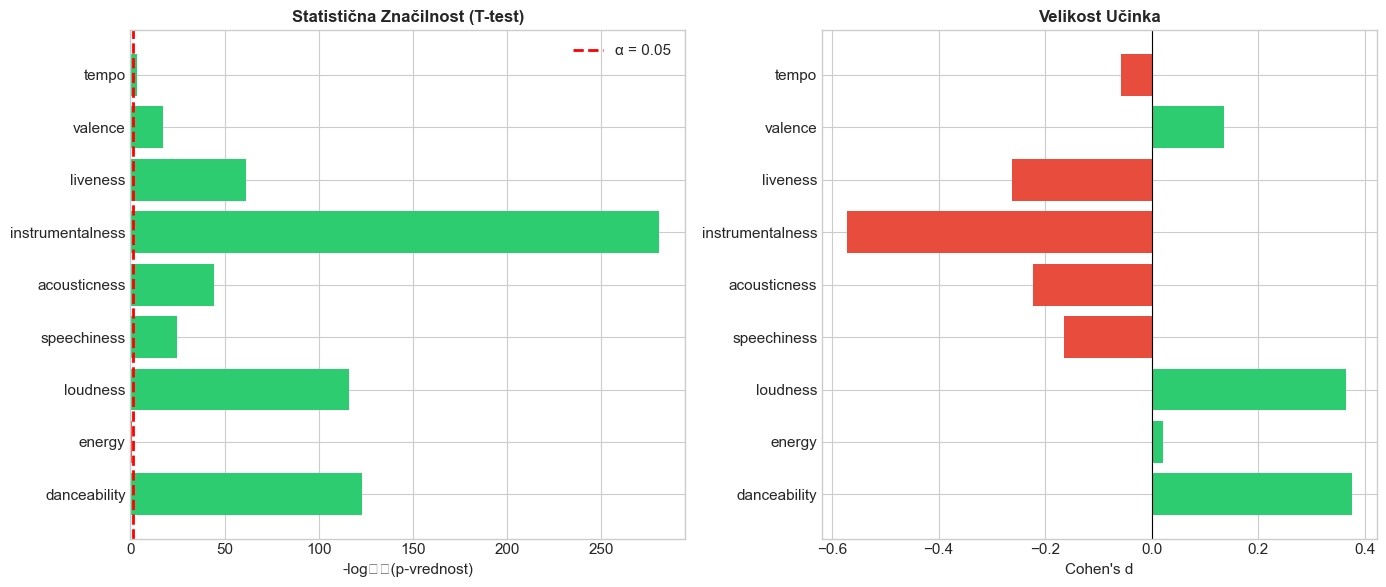

In [16]:
# T-TEST: Visoko vs Nizko priljubljene skladbe
print("=" * 70)
print("T-TEST: VISOKO PRILJUBLJENE vs NIZKO PRILJUBLJENE SKLADBE")
print("=" * 70)

high_pop = df[df['popularity_category'] == 'Visoka']
low_pop = df[df['popularity_category'] == 'Nizka']

print(f"\n📊 Visoko priljubljene: {len(high_pop):,} skladb")
print(f"📊 Nizko priljubljene: {len(low_pop):,} skladb\n")

ttest_results = []

for feature in AUDIO_FEATURES:
    t_stat, p_value = ttest_ind(high_pop[feature], low_pop[feature])
    
    # Cohen's d
    pooled_std = np.sqrt(((len(high_pop)-1)*high_pop[feature].std()**2 + 
                          (len(low_pop)-1)*low_pop[feature].std()**2) / 
                         (len(high_pop) + len(low_pop) - 2))
    cohens_d = (high_pop[feature].mean() - low_pop[feature].mean()) / pooled_std
    
    effect_size = 'Velik' if abs(cohens_d) >= 0.8 else 'Srednji' if abs(cohens_d) >= 0.5 else 'Majhen' if abs(cohens_d) >= 0.2 else 'Zanemarljiv'
    
    ttest_results.append({
        'Značilnost': feature,
        'Povp. (Visoka)': round(high_pop[feature].mean(), 3),
        'Povp. (Nizka)': round(low_pop[feature].mean(), 3),
        't-stat': round(t_stat, 2),
        'p-vrednost': p_value,
        "Cohen's d": round(cohens_d, 3),
        'Učinek': effect_size,
        'Značilno': '✓' if p_value < 0.05 else '✗'
    })

ttest_df = pd.DataFrame(ttest_results)
print(ttest_df.to_string(index=False))

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

significant = ttest_df['p-vrednost'] < 0.05
colors = ['#2ecc71' if sig else '#e74c3c' for sig in significant]
axes[0].barh(ttest_df['Značilnost'], -np.log10(ttest_df['p-vrednost']), color=colors)
axes[0].axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[0].set_xlabel('-log₁₀(p-vrednost)')
axes[0].set_title('Statistična Značilnost (T-test)', fontsize=12, fontweight='bold')
axes[0].legend()

colors_d = ['#2ecc71' if d > 0 else '#e74c3c' for d in ttest_df["Cohen's d"]]
axes[1].barh(ttest_df['Značilnost'], ttest_df["Cohen's d"], color=colors_d)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Cohen's d")
axes[1].set_title('Velikost Učinka', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/09_ttest_results.png', dpi=150, bbox_inches='tight')
plt.show()


ANOVA: RAZLIKE V ZVOČNIH ZNAČILNOSTIH MED ŽANRI

📊 Žanri v analizi: acoustic, afrobeat, alt-rock, ambient, cantopop, tango, chicago-house, forro, bluegrass, study
      Značilnost  F-stat    p-vrednost     η²  Učinek Značilno
    danceability  857.92  0.000000e+00 0.4363   Velik        ✓
          energy 1130.68  0.000000e+00 0.5049   Velik        ✓
        loudness  857.18  0.000000e+00 0.4361   Velik        ✓
     speechiness  167.50 8.701961e-297 0.1313 Srednji        ✓
    acousticness 1113.19  0.000000e+00 0.5010   Velik        ✓
instrumentalness 1281.30  0.000000e+00 0.5361   Velik        ✓
        liveness   90.99 1.151101e-163 0.0759 Srednji        ✓
         valence  735.49  0.000000e+00 0.3988   Velik        ✓
           tempo   95.37 1.723364e-171 0.0792 Srednji        ✓


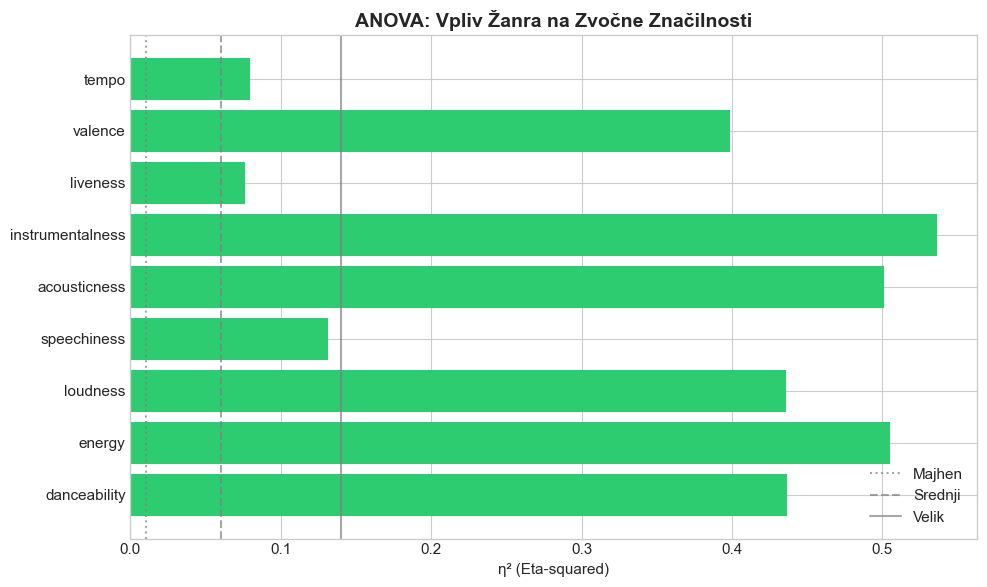

In [17]:
# ANOVA: Razlike med žanri
print("\n" + "=" * 70)
print("ANOVA: RAZLIKE V ZVOČNIH ZNAČILNOSTIH MED ŽANRI")
print("=" * 70)

# Izberemo top 10 žanrov za ANOVA
top_genres = df['genre'].value_counts().head(10).index.tolist()
df_anova = df[df['genre'].isin(top_genres)]

print(f"\n📊 Žanri v analizi: {', '.join(top_genres)}")

anova_results = []

for feature in AUDIO_FEATURES:
    groups = [df_anova[df_anova['genre'] == g][feature].values for g in top_genres]
    f_stat, p_value = f_oneway(*groups)
    
    # Eta-squared
    grand_mean = df_anova[feature].mean()
    ss_between = sum(len(df_anova[df_anova['genre'] == g]) * 
                    (df_anova[df_anova['genre'] == g][feature].mean() - grand_mean)**2 
                    for g in top_genres)
    ss_total = sum((df_anova[feature] - grand_mean)**2)
    eta_squared = ss_between / ss_total
    
    effect = 'Velik' if eta_squared >= 0.14 else 'Srednji' if eta_squared >= 0.06 else 'Majhen' if eta_squared >= 0.01 else 'Zanemarljiv'
    
    anova_results.append({
        'Značilnost': feature,
        'F-stat': round(f_stat, 2),
        'p-vrednost': p_value,
        'η²': round(eta_squared, 4),
        'Učinek': effect,
        'Značilno': '✓' if p_value < 0.05 else '✗'
    })

anova_df = pd.DataFrame(anova_results)
print(anova_df.to_string(index=False))

# Vizualizacija
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if sig == '✓' else '#e74c3c' for sig in anova_df['Značilno']]
ax.barh(anova_df['Značilnost'], anova_df['η²'], color=colors)
ax.axvline(0.01, color='gray', linestyle=':', alpha=0.7, label='Majhen')
ax.axvline(0.06, color='gray', linestyle='--', alpha=0.7, label='Srednji')
ax.axvline(0.14, color='gray', linestyle='-', alpha=0.7, label='Velik')
ax.set_xlabel('η² (Eta-squared)')
ax.set_title('ANOVA: Vpliv Žanra na Zvočne Značilnosti', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/10_anova_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analiza Glavnih Komponent (PCA)

**📊 Podatkovni vir: Kaggle CSV dataset**

### Zmanjšanje Dimenzionalnosti

**Namen:** 
- Zmanjšanje 9 zvočnih značilnosti na 2-3 glavne komponente
- Vizualizacija podatkov v 2D prostoru
- Identifikacija, katere značilnosti največ prispevajo k variabilnosti

**Vprašanje:** Ali se skladbe različnih žanrov ali različne priljubljenosti grupirajo v PCA prostoru?

**Zakaj ta vizualizacija ni redundantna:** 
PCA omogoča prikaz vseh značilnosti hkrati v 2D prostoru, kar histogrami in scatter ploti ne omogočajo.

PCA - ANALIZA GLAVNIH KOMPONENT

📈 Pojasnjena varianca:
   PC1: 32.12% (Kumulativno: 32.12%)
   PC2: 15.87% (Kumulativno: 47.99%)
   PC3: 13.89% (Kumulativno: 61.88%)
   PC4: 10.00% (Kumulativno: 71.88%)
   PC5: 9.69% (Kumulativno: 81.57%)
   PC6: 8.17% (Kumulativno: 89.74%)
   PC7: 5.07% (Kumulativno: 94.81%)
   PC8: 3.63% (Kumulativno: 98.44%)
   PC9: 1.56% (Kumulativno: 100.00%)


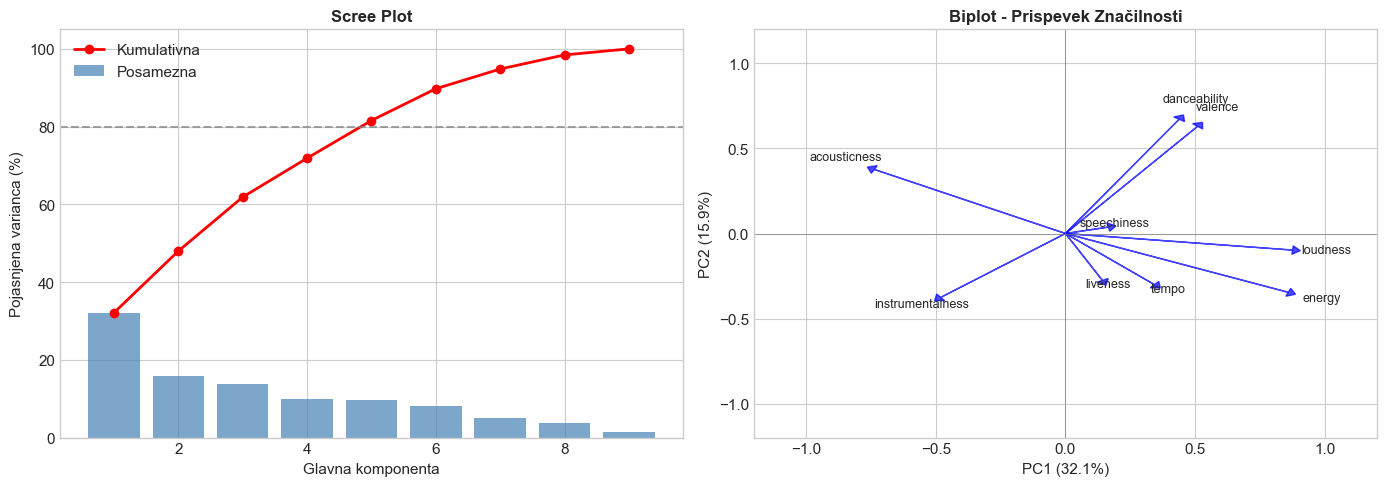

In [18]:
# PCA analiza
print("=" * 60)
print("PCA - ANALIZA GLAVNIH KOMPONENT")
print("=" * 60)

# Standardizacija
X = df[AUDIO_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\n📈 Pojasnjena varianca:")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"   PC{i+1}: {ev*100:.2f}% (Kumulativno: {cv*100:.2f}%)")

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance)+1), explained_variance * 100, 
            color='steelblue', alpha=0.7, label='Posamezna')
axes[0].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, 
             'ro-', linewidth=2, label='Kumulativna')
axes[0].axhline(y=80, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Glavna komponenta')
axes[0].set_ylabel('Pojasnjena varianca (%)')
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].legend()

# Biplot
loadings = pca_full.components_.T * np.sqrt(pca_full.explained_variance_)
for i, feature in enumerate(AUDIO_FEATURES):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1], 
                  head_width=0.05, head_length=0.03, fc='blue', ec='blue', alpha=0.7)
    axes[1].text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, fontsize=9, ha='center')

axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[1].set_title('Biplot - Prispevek Značilnosti', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/11_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

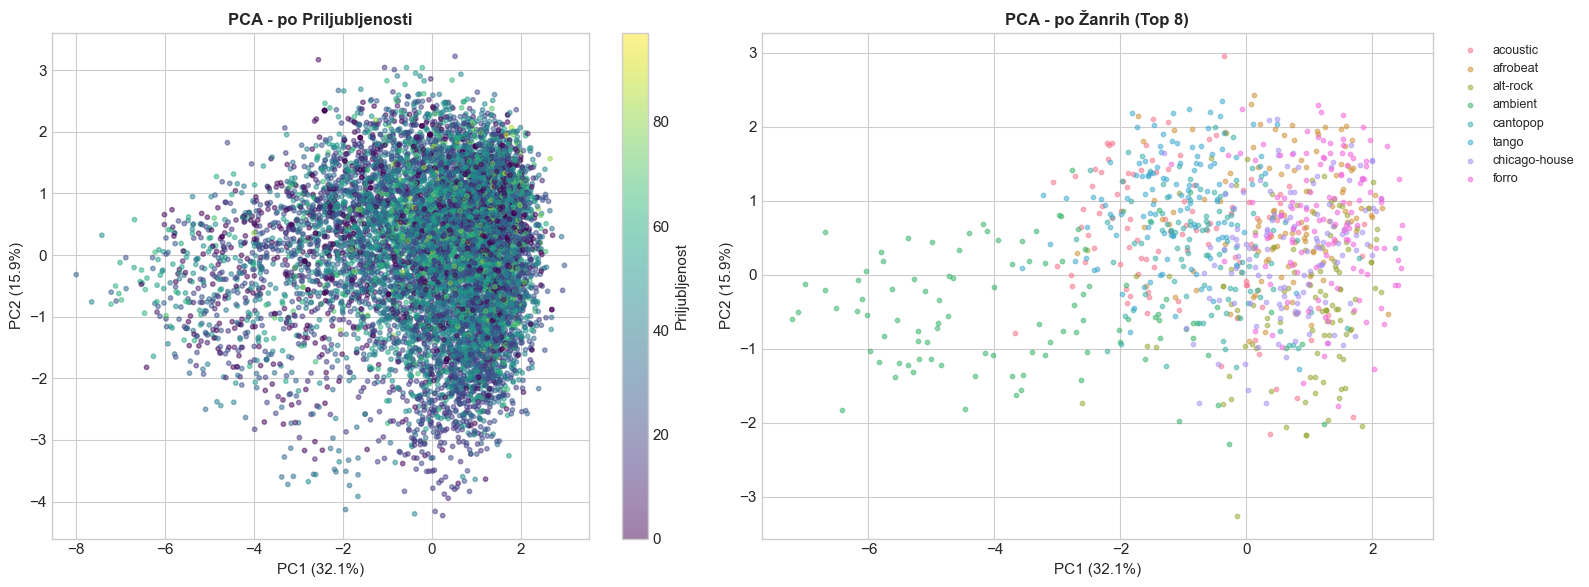


📊 Interpretacija PC komponent:

   PC1 Loadings:
      loudness: 0.515
      energy: 0.505
      acousticness: -0.433
      valence: 0.299
      instrumentalness: -0.283
      danceability: 0.258
      tempo: 0.202
      speechiness: 0.097
      liveness: 0.084


In [19]:
# PCA projekcija v 2D
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Vzorčenje za vizualizacijo
sample_size = min(10000, len(df))
df_sample = df.sample(sample_size, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Po priljubljenosti
scatter1 = axes[0].scatter(df_sample['PC1'], df_sample['PC2'], 
                           c=df_sample['popularity'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA - po Priljubljenosti', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Priljubljenost')

# Po žanrih (top 8)
top_8_genres = df['genre'].value_counts().head(8).index.tolist()
df_top_genres = df_sample[df_sample['genre'].isin(top_8_genres)]
colors = sns.color_palette("husl", 8)

for genre, color in zip(top_8_genres, colors):
    mask = df_top_genres['genre'] == genre
    axes[1].scatter(df_top_genres.loc[mask, 'PC1'], df_top_genres.loc[mask, 'PC2'], 
                   label=genre, alpha=0.5, s=10, color=color)

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA - po Žanrih (Top 8)', fontsize=12, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/12_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretacija PC komponent:")
print("\n   PC1 Loadings:")
pc1_loadings = pd.Series(pca_2d.components_[0], index=AUDIO_FEATURES).sort_values(key=abs, ascending=False)
for feature, loading in pc1_loadings.items():
    print(f"      {feature}: {loading:.3f}")

## 7. Clustering - Identifikacija Glasbenih Profilov

**📊 Podatkovni vir: Kaggle CSV dataset**

### K-Means Clustering

**Namen:** Identifikacija značilnih tipov skladb (glasbenih profilov) na podlagi zvočnih značilnosti.

**Vprašanje:** Ali obstajajo naravne skupine skladb z značilnimi zvočnimi profili, neodvisno od žanrske oznake?

**Zakaj ta analiza ni redundantna:**
- PCA prikazuje podatke v zmanjšanem prostoru, clustering pa jih **grupira**
- Žanri so subjektivne oznake, clustri so **podatkovni** profili

K-MEANS CLUSTERING

📊 Iskanje optimalnega K...
   K=2: Silhouette=0.2680
   K=3: Silhouette=0.1628
   K=4: Silhouette=0.1724
   K=5: Silhouette=0.1757
   K=6: Silhouette=0.1896
   K=7: Silhouette=0.1933
   K=8: Silhouette=0.1751
   K=9: Silhouette=0.1782
   K=10: Silhouette=0.1662


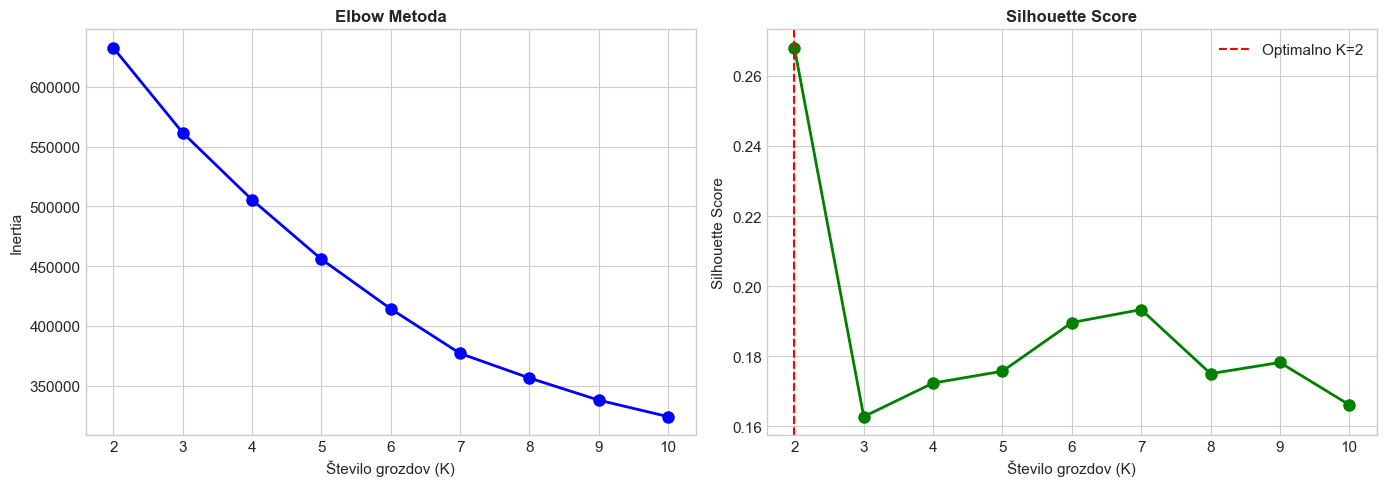


✅ Optimalno K (po Silhouette): 2


In [20]:
# Določitev optimalnega K
print("=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

K_range = range(2, 11)
inertias = []
silhouette_scores_list = []

print("\n📊 Iskanje optimalnega K...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_, sample_size=10000)
    silhouette_scores_list.append(sil_score)
    print(f"   K={k}: Silhouette={sil_score:.4f}")

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Število grozdov (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Metoda', fontsize=12, fontweight='bold')

axes[1].plot(K_range, silhouette_scores_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Število grozdov (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')

optimal_k = K_range[np.argmax(silhouette_scores_list)]
axes[1].axvline(optimal_k, color='red', linestyle='--', label=f'Optimalno K={optimal_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/13_clustering_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Optimalno K (po Silhouette): {optimal_k}")

📊 K-Means z 5 grozdi:
   Grozd 0: 33,656 skladb (37.5%)
   Grozd 1: 7,298 skladb (8.1%)
   Grozd 2: 26,861 skladb (29.9%)
   Grozd 3: 20,824 skladb (23.2%)
   Grozd 4: 1,102 skladb (1.2%)


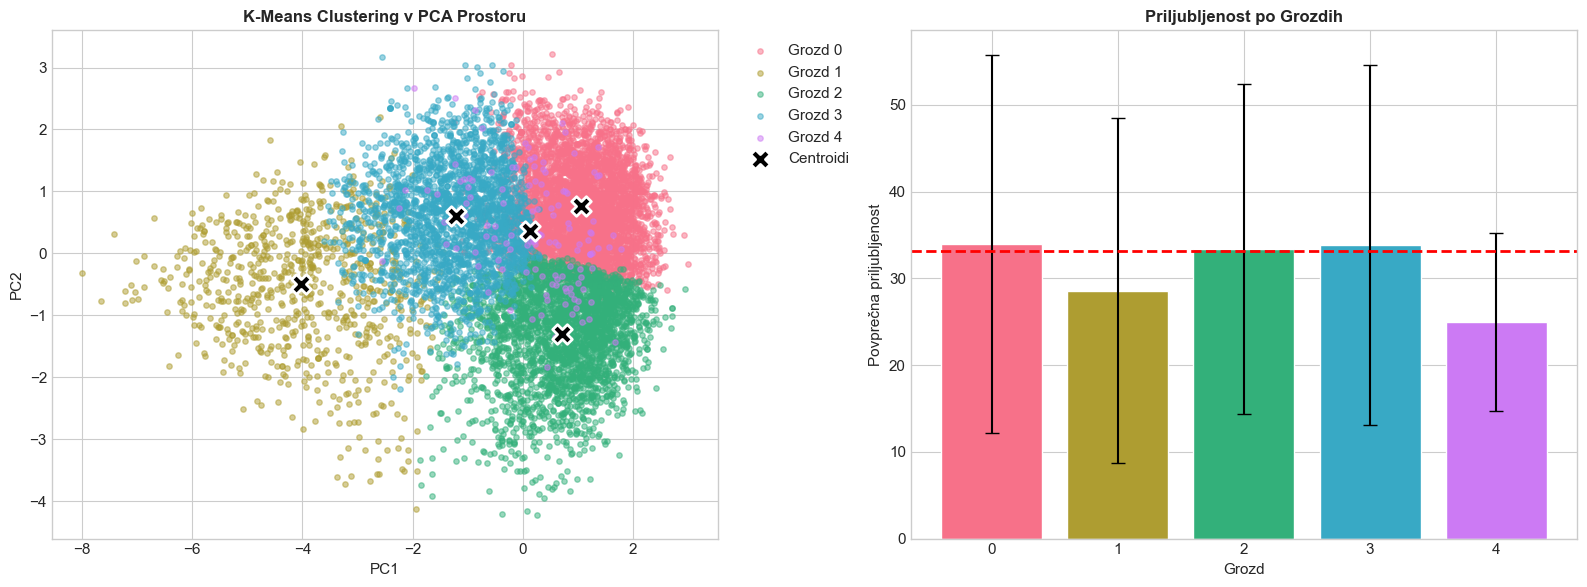

In [21]:
# K-Means z izbranim K (uporabimo 5 za interpretabilnost)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"📊 K-Means z {n_clusters} grozdi:")
cluster_counts = df['cluster'].value_counts().sort_index()
for i, count in cluster_counts.items():
    print(f"   Grozd {i}: {count:,} skladb ({count/len(df)*100:.1f}%)")

# Posodobi df_sample s cluster vrednostmi
df_sample['cluster'] = df.loc[df_sample.index, 'cluster']

# Vizualizacija v PCA prostoru
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = sns.color_palette("husl", n_clusters)
for i in range(n_clusters):
    mask = df_sample['cluster'] == i
    if mask.sum() > 0:
        axes[0].scatter(df_sample.loc[mask, 'PC1'], df_sample.loc[mask, 'PC2'], 
                       label=f'Grozd {i}', alpha=0.5, s=15, color=cluster_colors[i])

centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
               c='black', marker='X', s=200, edgecolors='white', linewidths=2, label='Centroidi')
axes[0].set_xlabel(f'PC1')
axes[0].set_ylabel(f'PC2')
axes[0].set_title('K-Means Clustering v PCA Prostoru', fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Priljubljenost po grozdih
cluster_pop = df.groupby('cluster')['popularity'].agg(['mean', 'std']).reset_index()
bars = axes[1].bar(cluster_pop['cluster'], cluster_pop['mean'], yerr=cluster_pop['std'], 
                   capsize=5, color=cluster_colors, edgecolor='white')
axes[1].axhline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Grozd')
axes[1].set_ylabel('Povprečna priljubljenost')
axes[1].set_title('Priljubljenost po Grozdih', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/14_clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()


KARAKTERIZACIJA GLASBENIH TRENDOV (GROZDOV)

📊 Profili grozdov:

GROZD 0: 😊 Feel-Good
Skladb: 33,656
Povp. priljubljenost: 34.0

Značilnosti:
   danceability      : 0.693 █████████████
   energy            : 0.730 ██████████████
   speechiness       : 0.093 █
   acousticness      : 0.207 ████
   instrumentalness  : 0.065 █
   liveness          : 0.194 ███
   valence           : 0.693 █████████████

GROZD 1: 🎸 Acoustic/Mellow
Skladb: 7,298
Povp. priljubljenost: 28.6

Značilnosti:
   danceability      : 0.353 ███████
   energy            : 0.198 ███
   speechiness       : 0.052 █
   acousticness      : 0.821 ████████████████
   instrumentalness  : 0.781 ███████████████
   liveness          : 0.172 ███
   valence           : 0.179 ███

GROZD 2: 🔥 High Energy
Skladb: 26,861
Povp. priljubljenost: 33.4

Značilnosti:
   danceability      : 0.476 █████████
   energy            : 0.821 ████████████████
   speechiness       : 0.084 █
   acousticness      : 0.068 █
   instrumentalness  : 0.238 █

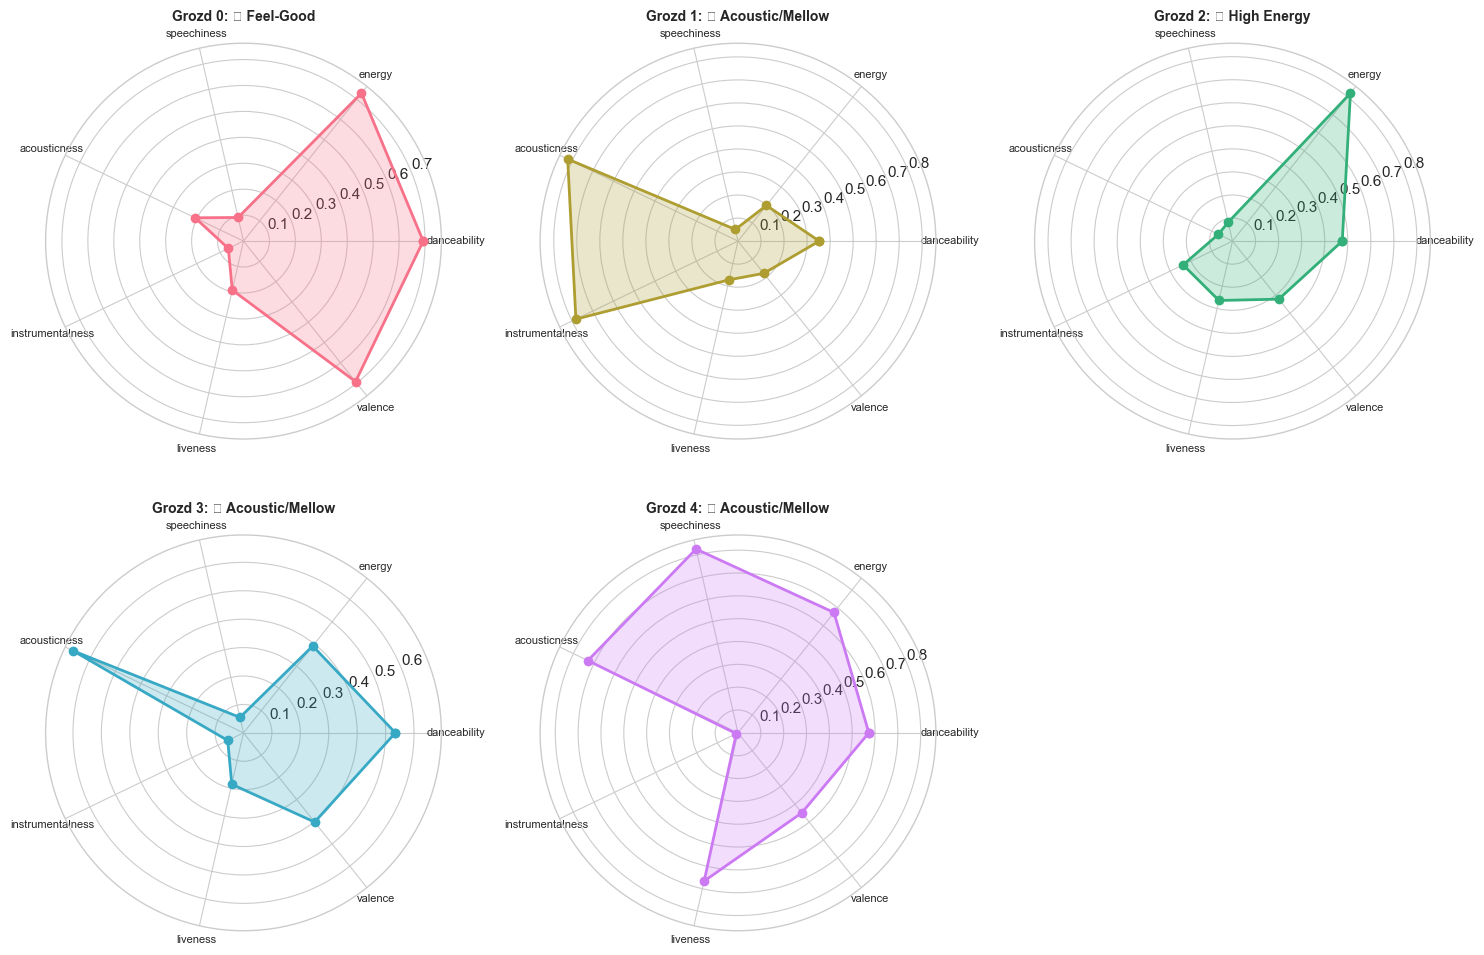

In [22]:
# Karakterizacija grozdov
print("\n" + "=" * 70)
print("KARAKTERIZACIJA GLASBENIH TRENDOV (GROZDOV)")
print("=" * 70)

cluster_profiles = df.groupby('cluster')[AUDIO_FEATURES + ['popularity']].mean()

# Avtomatska poimenovanja
cluster_names = {}
for i in range(n_clusters):
    profile = cluster_profiles.loc[i]
    if profile['danceability'] > 0.7 and profile['energy'] > 0.7:
        name = "🎉 Party/Club"
    elif profile['acousticness'] > 0.6:
        name = "🎸 Acoustic/Mellow"
    elif profile['energy'] > 0.8:
        name = "🔥 High Energy"
    elif profile['valence'] > 0.6 and profile['danceability'] > 0.6:
        name = "😊 Feel-Good"
    elif profile['speechiness'] > 0.15:
        name = "🎤 Vocal/Speech"
    elif profile['instrumentalness'] > 0.5:
        name = "🎹 Instrumental"
    else:
        name = f"🎵 Mixed {i}"
    cluster_names[i] = name

print("\n📊 Profili grozdov:\n")
for i in range(n_clusters):
    print(f"{'='*50}")
    print(f"GROZD {i}: {cluster_names[i]}")
    print(f"{'='*50}")
    print(f"Skladb: {(df['cluster'] == i).sum():,}")
    print(f"Povp. priljubljenost: {cluster_profiles.loc[i, 'popularity']:.1f}")
    print("\nZnačilnosti:")
    for feature in AUDIO_FEATURES_NORMALIZED:
        val = cluster_profiles.loc[i, feature]
        bar = '█' * int(val * 20)
        print(f"   {feature:18s}: {val:.3f} {bar}")
    print()

# Radar chart za grozde
from math import pi

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))
categories = AUDIO_FEATURES_NORMALIZED
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for idx, ax in enumerate(axes.flatten()[:n_clusters]):
    values = cluster_profiles.loc[idx, AUDIO_FEATURES_NORMALIZED].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=cluster_colors[idx])
    ax.fill(angles, values, alpha=0.25, color=cluster_colors[idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_title(f'Grozd {idx}: {cluster_names[idx]}', fontsize=10, fontweight='bold')

if n_clusters < 6:
    axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/15_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Regresijski Modeli - Napoved Priljubljenosti

**📊 Podatkovni vir: Kaggle CSV dataset**

### Namen
Ugotoviti, ali lahko na podlagi zvočnih značilnosti napovemo priljubljenost skladbe.

### Modeli
| Model | Tip | Namen |
|-------|-----|-------|
| Linearna regresija | Baseline | Referenčni model |
| Ridge regresija | Regularizirana | Preprečevanje overfittinga |
| Random Forest | Ensemble | Nelinearni odnosi |
| Gradient Boosting | Ensemble | Kompleksni vzorci |

### Vprašanje
Ali zvočne značilnosti zadoščajo za napoved priljubljenosti, ali so potrebni dodatni faktorji (marketing, izvajalec, čas izdaje)?

### Zakaj ta analiza ni redundantna
- Korelacije pokažejo **linearne** povezave
- Regresija testira **napovedno moč** vseh značilnosti skupaj

In [23]:
# Regresijski modeli
print("=" * 60)
print("REGRESIJSKI MODELI ZA NAPOVED PRILJUBLJENOSTI")
print("=" * 60)

X = df[AUDIO_FEATURES].copy()
y = df['popularity'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📊 Učna množica: {len(X_train):,}")
print(f"📊 Testna množica: {len(X_test):,}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linearna regresija': LinearRegression(),
    'Ridge regresija': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
print("\n🔄 Treniranje modelov...")

for name, model in models.items():
    print(f"   {name}...")
    
    if name in ['Random Forest', 'Gradient Boosting']:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 4),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)': round(cv_scores.std(), 4)
    })

results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("PRIMERJAVA MODELOV")
print("=" * 70)
print(results_df.to_string(index=False))

REGRESIJSKI MODELI ZA NAPOVED PRILJUBLJENOSTI

📊 Učna množica: 71,792
📊 Testna množica: 17,949

🔄 Treniranje modelov...
   Linearna regresija...
   Ridge regresija...
   Random Forest...
   Gradient Boosting...

PRIMERJAVA MODELOV
             Model   RMSE    MAE     R²  CV R² (mean)  CV R² (std)
Linearna regresija 20.147 16.599 0.0283        0.0306       0.0027
   Ridge regresija 20.147 16.599 0.0283        0.0306       0.0027
     Random Forest 17.922 13.747 0.2311        0.2164       0.0089
 Gradient Boosting 19.553 15.853 0.0847        0.0916       0.0037


## 9. Evalvacija Modelov in Pomembnost Značilnosti

Analiziramo:
- Primerjavo uspešnosti modelov
- Pomembnost posameznih zvočnih značilnosti
- Residuale najboljšega modela

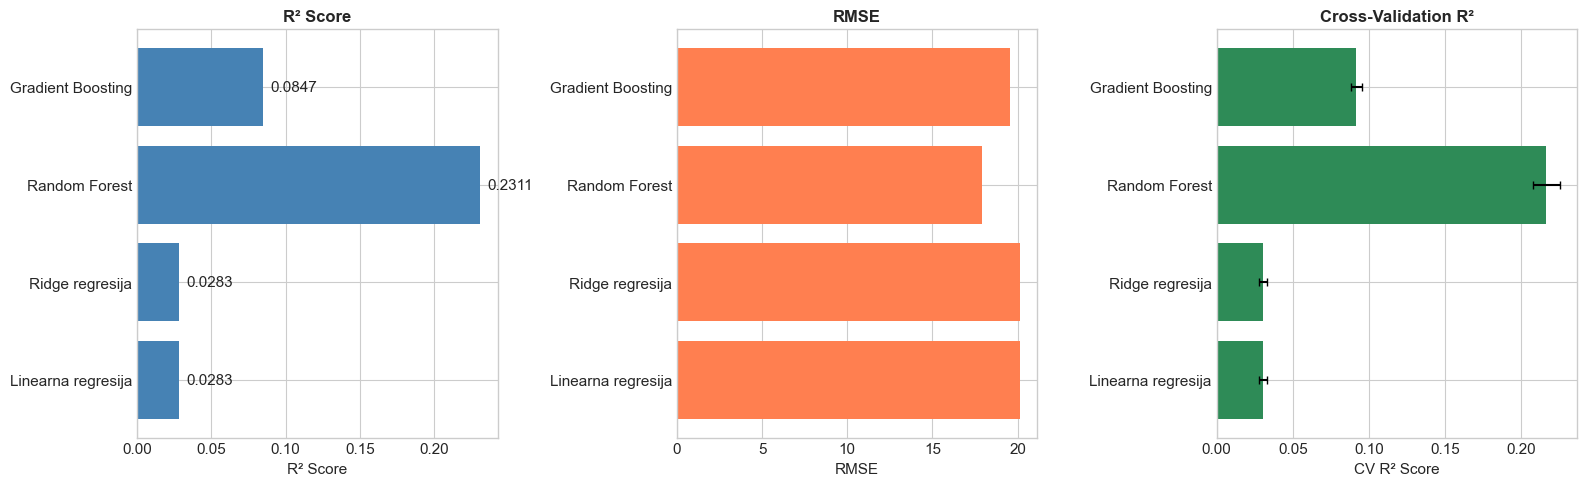


🏆 Najboljši model: Random Forest (R² = 0.2311)


In [24]:
# Vizualizacija primerjave modelov
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R²
axes[0].barh(results_df['Model'], results_df['R²'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score', fontsize=12, fontweight='bold')
for i, val in enumerate(results_df['R²']):
    axes[0].text(val + 0.005, i, f'{val:.4f}', va='center')

# RMSE
axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE', fontsize=12, fontweight='bold')

# CV R²
axes[2].barh(results_df['Model'], results_df['CV R² (mean)'], 
             xerr=results_df['CV R² (std)'], color='seagreen', capsize=3)
axes[2].set_xlabel('CV R² Score')
axes[2].set_title('Cross-Validation R²', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/16_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_idx = results_df['R²'].idxmax()
print(f"\n🏆 Najboljši model: {results_df.loc[best_idx, 'Model']} (R² = {results_df.loc[best_idx, 'R²']:.4f})")


POMEMBNOST ZNAČILNOSTI

📊 Random Forest - Pomembnost:
      Značilnost  Pomembnost
    acousticness    0.128110
    danceability    0.117152
           tempo    0.116784
         valence    0.112737
        loudness    0.112583
     speechiness    0.112572
          energy    0.105521
        liveness    0.103982
instrumentalness    0.090559


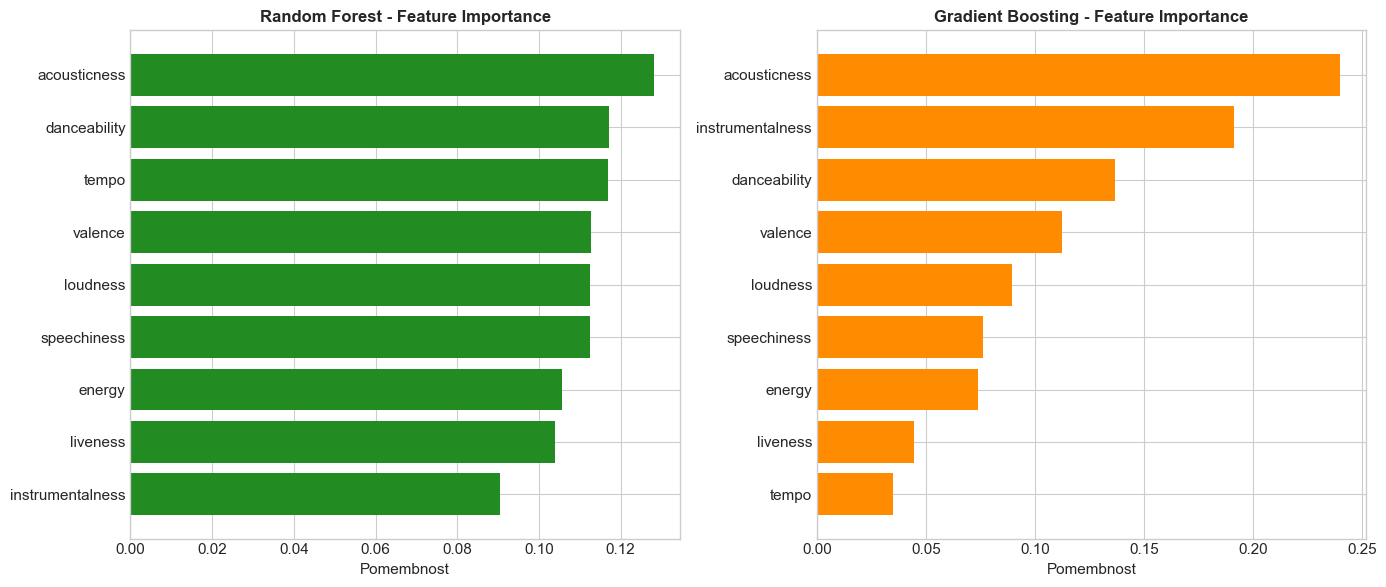

In [25]:
# Pomembnost značilnosti
print("\n" + "=" * 60)
print("POMEMBNOST ZNAČILNOSTI")
print("=" * 60)

rf_model = models['Random Forest']
rf_importance = pd.DataFrame({
    'Značilnost': AUDIO_FEATURES,
    'Pomembnost': rf_model.feature_importances_
}).sort_values('Pomembnost', ascending=False)

print("\n📊 Random Forest - Pomembnost:")
print(rf_importance.to_string(index=False))

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_sorted = rf_importance.sort_values('Pomembnost', ascending=True)
axes[0].barh(rf_sorted['Značilnost'], rf_sorted['Pomembnost'], color='forestgreen')
axes[0].set_xlabel('Pomembnost')
axes[0].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')

gb_model = models['Gradient Boosting']
gb_importance = pd.DataFrame({
    'Značilnost': AUDIO_FEATURES,
    'Pomembnost': gb_model.feature_importances_
}).sort_values('Pomembnost', ascending=True)

axes[1].barh(gb_importance['Značilnost'], gb_importance['Pomembnost'], color='darkorange')
axes[1].set_xlabel('Pomembnost')
axes[1].set_title('Gradient Boosting - Feature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/17_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

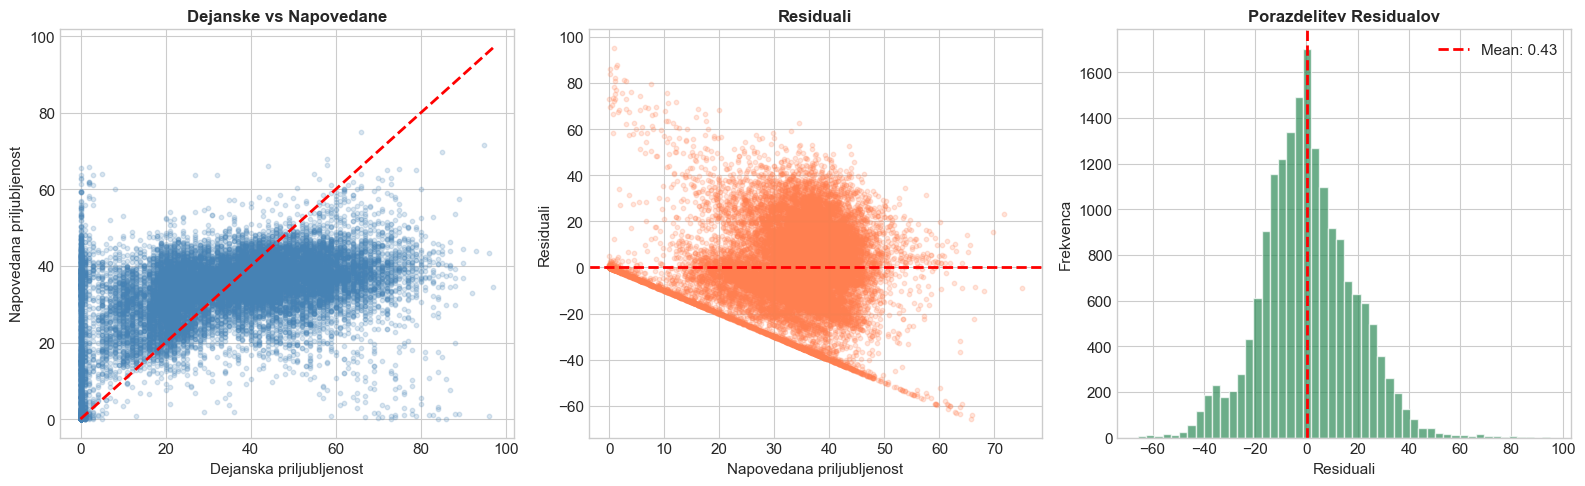

In [26]:
# Analiza residualov
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Dejanske vs napovedane
axes[0].scatter(y_test, y_pred_best, alpha=0.2, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Dejanska priljubljenost')
axes[0].set_ylabel('Napovedana priljubljenost')
axes[0].set_title('Dejanske vs Napovedane', fontsize=12, fontweight='bold')

# Residuali
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Napovedana priljubljenost')
axes[1].set_ylabel('Residuali')
axes[1].set_title('Residuali', fontsize=12, fontweight='bold')

# Porazdelitev residualov
axes[2].hist(residuals, bins=50, color='seagreen', edgecolor='white', alpha=0.7)
axes[2].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {residuals.mean():.2f}')
axes[2].set_xlabel('Residuali')
axes[2].set_ylabel('Frekvenca')
axes[2].set_title('Porazdelitev Residualov', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/18_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Primerjava Glasbenih Trendov po Državah

### Metodološki Okvir

**Raziskovalno vprašanje:**
Kako se zvočni profili trenutno priljubljenih skladb razlikujejo med slovenskim in globalnimi trgi?

### Podatkovni Viri in Njihove Vloge

| Vir | Podatki | Namen |
|-----|---------|-------|
| **Spotify API** | Track ID, ime, izvajalec, popularity | Identifikacija trenutnih trendov |
| **Kaggle CSV** | Audio features (danceability, energy...) | Analiza zvočnih profilov |

### Postopek Analize

```
1. API: Pridobi Top 50 skladbe za vsako državo
   ↓
2. API: Pridobi track_id in metadata za vsako skladbo
   ↓
3. CSV: Poišči audio features za track_id v Kaggle datasetu
   ↓
4. Analiza: Primerjaj zvočne profile med državami
```

### Države v Primerjavi

| Država | Playlist | Značilnost trga |
|--------|----------|-----------------|
| 🇸🇮 Slovenija | Top 50 Slovenia | Majhen trg, lokalni vplivi |
| 🇺🇸 ZDA | Top 50 USA | Največji trg, globalni trendsetter |
| 🇬🇧 UK | Top 50 UK | Velik trg, evropski vpliv |
| 🌍 Global | Top 50 Global | Agregat vseh trgov |

### ⚠️ Metodološke Omejitve

1. **API vrača snapshot** - trenutno stanje, ne zgodovinske trende
2. **Ujemanje track_id** - nekatere skladbe iz API morda niso v CSV datasetu
3. **Reprezentativnost** - Top 50 ne predstavlja celotnega trga

### Alternativni Pristop (če API ni na voljo)

Če Spotify API ni dostopen, uporabimo **simulirane podatke** iz CSV dataseta:
- Vzorčimo skladbe iz žanrov, značilnih za posamezno državo
- To NI realen podatek, ampak demonstracija metodologije

In [27]:
# =============================================================================
# PRIMERJAVA DRŽAV: PRIDOBIVANJE PODATKOV
# =============================================================================
# Metoda: API za identifikacijo trendov + CSV za audio features
# =============================================================================

# Spotify Official Playlist IDs (Top 50 po državah)
COUNTRY_PLAYLISTS = {
    'Global': '37i9dQZEVXbMDoHDwVN2tF',
    'USA': '37i9dQZEVXbLRQDuF5jeBp',
    'UK': '37i9dQZEVXbLnolsZ8PSNw',
    'Slovenia': '37i9dQZEVXbMH2jvi6jvjk'
}

def get_country_trends_with_csv_features(sp, playlist_id, country_name, csv_df):
    """
    Hibridna funkcija: API za track metadata + CSV za audio features.
    
    Postopek:
    1. API: Pridobi track IDs iz playliste
    2. CSV: Poišči audio features za te track IDs
    3. Vrni združene podatke
    
    OPOMBA: Audio features NE pridobivamo iz API-ja!
    """
    if sp is None:
        return None, 0, 0
    
    try:
        # KORAK 1: Pridobi metapodatke iz API
        results = sp.playlist_tracks(playlist_id, limit=50)
        tracks = results['items']
        
        api_data = []
        track_ids = []
        
        for item in tracks:
            track = item['track']
            if track and track['id']:
                track_ids.append(track['id'])
                api_data.append({
                    'track_id': track['id'],
                    'track_name': track['name'],
                    'artist': track['artists'][0]['name'] if track['artists'] else 'Unknown',
                    'api_popularity': track['popularity'],
                    'country': country_name
                })
        
        df_api = pd.DataFrame(api_data)
        
        # KORAK 2: Poišči audio features v CSV datasetu
        # Ujemanje po track_id
        df_merged = df_api.merge(
            csv_df[['track_id'] + AUDIO_FEATURES],
            on='track_id',
            how='inner'
        )
        
        n_api = len(df_api)
        n_matched = len(df_merged)
        
        return df_merged, n_api, n_matched
    
    except Exception as e:
        print(f"   ⚠️ Napaka pri {country_name}: {e}")
        return None, 0, 0

# =============================================================================
# PRIDOBIVANJE PODATKOV
# =============================================================================

country_data = {}
api_stats = {}

print("=" * 70)
print("PRIDOBIVANJE PODATKOV O TRENDIH PO DRŽAVAH")
print("=" * 70)
print("\n📋 Metoda: Spotify API (metadata) + Kaggle CSV (audio features)")
print("   ⚠️  Audio features NE pridobivamo iz API-ja!\n")

if sp is not None:
    print("🌍 Pridobivanje podatkov iz Spotify API + CSV...")
    print("-" * 50)
    
    for country, playlist_id in COUNTRY_PLAYLISTS.items():
        print(f"   → {country}...", end=" ")
        
        df_country, n_api, n_matched = get_country_trends_with_csv_features(
            sp, playlist_id, country, df
        )
        
        if df_country is not None and len(df_country) > 0:
            country_data[country] = df_country
            api_stats[country] = {'api_tracks': n_api, 'matched': n_matched}
            match_rate = n_matched / n_api * 100 if n_api > 0 else 0
            print(f"✅ API: {n_api} | CSV match: {n_matched} ({match_rate:.0f}%)")
        else:
            print(f"⚠️ Ni ujemanj v CSV (0/{n_api if n_api else '?'})")
    
    print("-" * 50)
    
    # Statistika ujemanja
    if api_stats:
        total_api = sum(s['api_tracks'] for s in api_stats.values())
        total_matched = sum(s['matched'] for s in api_stats.values())
        print(f"\n📊 Skupno: {total_matched}/{total_api} skladb ima audio features v CSV")
        if total_matched < total_api * 0.3:
            print("   ⚠️ Nizka stopnja ujemanja - razmislite o uporabi simuliranih podatkov")

# Če ni dovolj podatkov, uporabi simulirane podatke
if len(country_data) < 2 or all(len(d) < 10 for d in country_data.values()):
    print("\n" + "=" * 70)
    print("⚠️  UPORABA SIMULIRANIH PODATKOV")
    print("=" * 70)
    print("""
   Razlog: Premalo ujemanj med API in CSV podatki.
   
   Simulirani podatki so ustvarjeni iz CSV dataseta za demonstracijo
   metodologije. To NI realen podatek o trenutnih trendih!
   
   Za realne podatke bi potrebovali:
   • Dataset, ki vsebuje track_id skladb iz Spotify Top 50
   • Ali pa razširjeno kvoto za audio-features API endpoint
""")
    
    country_data = {}  # Reset
    
    # Simulacija: vzorčenje iz žanrov značilnih za države
    np.random.seed(42)
    
    country_genre_profiles = {
        'Global': ['pop', 'hip hop', 'dance', 'latin', 'r&b'],
        'USA': ['hip hop', 'pop', 'r&b', 'country', 'rock'],
        'UK': ['pop', 'dance', 'indie', 'rock', 'electronic'],
        'Slovenia': ['pop', 'rock', 'folk', 'dance', 'acoustic']
    }
    
    for country, genres in country_genre_profiles.items():
        # Ustvari regex pattern za iskanje žanrov
        pattern = '|'.join(genres)
        mask = df['genre'].str.lower().str.contains(pattern, na=False)
        
        sample_size = 40 if country != 'Slovenia' else 25
        
        if mask.sum() >= sample_size:
            sample = df[mask].sample(sample_size, random_state=hash(country) % 2**32)
        else:
            sample = df.sample(sample_size, random_state=hash(country) % 2**32)
        
        sample = sample.copy()
        sample['country'] = country
        sample['data_source'] = 'SIMULATED_CSV'  # Jasno označeno!
        country_data[country] = sample
        
        print(f"   → {country}: {len(sample)} skladb (SIMULIRANO)")

# Združi podatke
if country_data:
    df_countries = pd.concat(country_data.values(), ignore_index=True)
    
    print(f"\n{'=' * 70}")
    print(f"📊 KONČNI PODATKI: {len(df_countries)} skladb iz {len(country_data)} držav")
    print(f"{'=' * 70}")
    
    # Označi vir podatkov
    if 'data_source' in df_countries.columns:
        print("\n⚠️  OPOMBA: Podatki so SIMULIRANI iz CSV za demonstracijo metodologije!")
    else:
        print("\n✅ Podatki pridobljeni iz Spotify API + CSV audio features")
else:
    print("\n❌ Ni podatkov za primerjavo držav!")
    df_countries = pd.DataFrame()

PRIDOBIVANJE PODATKOV O TRENDIH PO DRŽAVAH

📋 Metoda: Spotify API (metadata) + Kaggle CSV (audio features)
   ⚠️  Audio features NE pridobivamo iz API-ja!

🌍 Pridobivanje podatkov iz Spotify API + CSV...
--------------------------------------------------
   → Global... 

HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZEVXbMDoHDwVN2tF/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': None, 'additional_types': 'track'} returned 404 due to Resource not found


   ⚠️ Napaka pri Global: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZEVXbMDoHDwVN2tF/tracks?limit=50&offset=0&additional_types=track:
 Resource not found, reason: None
⚠️ Ni ujemanj v CSV (0/?)
   → USA... 

HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZEVXbLRQDuF5jeBp/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': None, 'additional_types': 'track'} returned 404 due to Resource not found


   ⚠️ Napaka pri USA: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZEVXbLRQDuF5jeBp/tracks?limit=50&offset=0&additional_types=track:
 Resource not found, reason: None
⚠️ Ni ujemanj v CSV (0/?)
   → UK... 

HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZEVXbLnolsZ8PSNw/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': None, 'additional_types': 'track'} returned 404 due to Resource not found


   ⚠️ Napaka pri UK: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZEVXbLnolsZ8PSNw/tracks?limit=50&offset=0&additional_types=track:
 Resource not found, reason: None
⚠️ Ni ujemanj v CSV (0/?)
   → Slovenia... 

HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZEVXbMH2jvi6jvjk/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': None, 'additional_types': 'track'} returned 404 due to Resource not found


   ⚠️ Napaka pri Slovenia: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZEVXbMH2jvi6jvjk/tracks?limit=50&offset=0&additional_types=track:
 Resource not found, reason: None
⚠️ Ni ujemanj v CSV (0/?)
--------------------------------------------------

⚠️  UPORABA SIMULIRANIH PODATKOV

   Razlog: Premalo ujemanj med API in CSV podatki.

   Simulirani podatki so ustvarjeni iz CSV dataseta za demonstracijo
   metodologije. To NI realen podatek o trenutnih trendih!

   Za realne podatke bi potrebovali:
   • Dataset, ki vsebuje track_id skladb iz Spotify Top 50
   • Ali pa razširjeno kvoto za audio-features API endpoint

   → Global: 40 skladb (SIMULIRANO)
   → USA: 40 skladb (SIMULIRANO)
   → UK: 40 skladb (SIMULIRANO)
   → Slovenia: 25 skladb (SIMULIRANO)

📊 KONČNI PODATKI: 145 skladb iz 4 držav

⚠️  OPOMBA: Podatki so SIMULIRANI iz CSV za demonstracijo metodologije!


### 10.1 Primerjava Zvočnih Profilov po Državah

**Vizualizacija:** Radar chart primerjave zvočnih značilnosti med državami

**Podatkovni vir:** 
- Identifikacija trendov: Spotify API (Top 50 playliste)
- Audio features: Kaggle CSV dataset

**Raziskovalno vprašanje:** 
Kako se zvočni profil trenutno priljubljenih skladb razlikuje med slovenskim in globalnimi trgi?

**Interpretacija:**
- Razlike v `danceability` in `energy` kažejo na preference za različne tipe glasbe
- Višja `acousticness` lahko nakazuje večjo priljubljenost lokalne/akustične glasbe
- `valence` (pozitivnost) odraža razpoloženje trenutno priljubljene glasbe

**⚠️ Opomba:** Če so bili uporabljeni simulirani podatki, rezultati predstavljajo demonstracijo metodologije, ne realnih trendov.

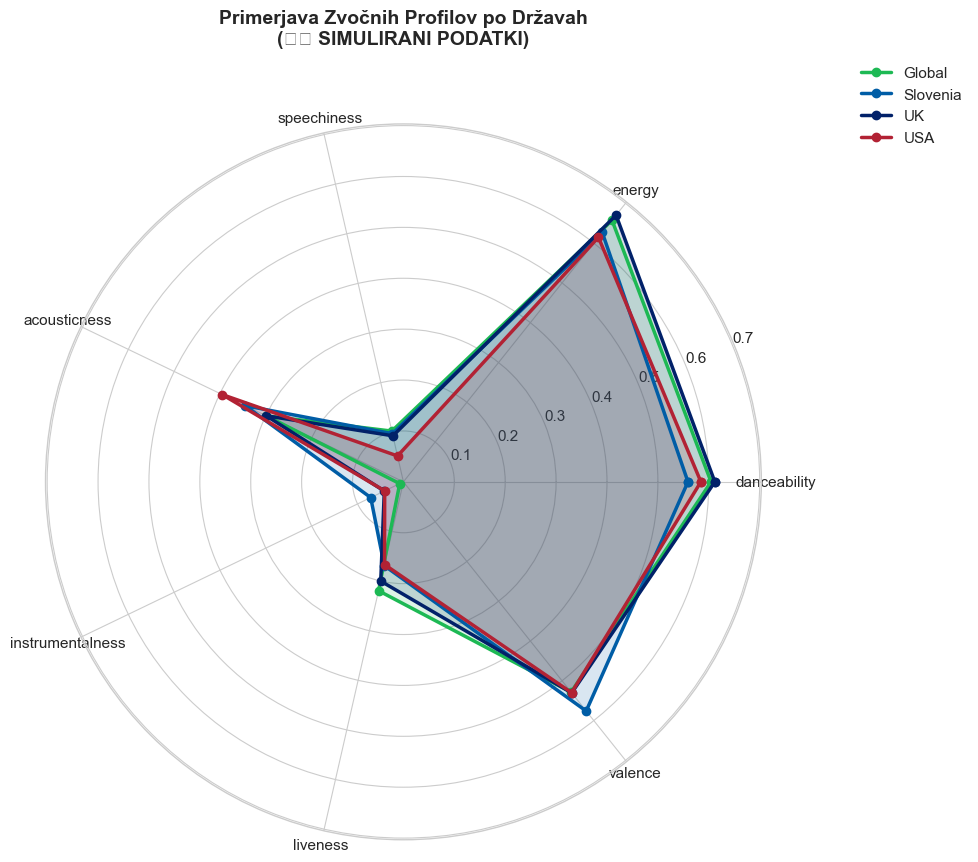


📊 Povprečne vrednosti zvočnih značilnosti po državah:
   Vir audio features: Kaggle CSV dataset
          danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence
country                                                                                       
Global           0.604   0.657        0.102         0.299             0.008     0.219    0.529
Slovenia         0.559   0.627        0.097         0.345             0.071     0.169    0.576
UK               0.612   0.670        0.093         0.299             0.042     0.200    0.530
USA              0.585   0.615        0.052         0.395             0.041     0.167    0.530


In [28]:
# =============================================================================
# VIZUALIZACIJA: Radar Chart - Primerjava Držav
# =============================================================================
# Vir: Audio features iz CSV (identificirano preko API ali simulirano)
# Namen: Primerjava zvočnih profilov med državami
# =============================================================================

from math import pi

if len(df_countries) > 0:
    # Izračunaj povprečja po državah
    country_profiles = df_countries.groupby('country')[AUDIO_FEATURES_NORMALIZED].mean()
    
    # Priprava za radar chart
    categories = AUDIO_FEATURES_NORMALIZED
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Barve za države
    country_colors = {
        'Slovenia': '#005DA6',  # Slovenska modra
        'USA': '#B22234',       # Ameriška rdeča
        'UK': '#012169',        # Britanska modra
        'Global': '#1DB954'     # Spotify zelena
    }
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    for country in country_profiles.index:
        values = country_profiles.loc[country].values.tolist()
        values += values[:1]
        color = country_colors.get(country, 'gray')
        ax.plot(angles, values, 'o-', linewidth=2.5, label=country, color=color)
        ax.fill(angles, values, alpha=0.15, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    
    # Naslov z oznako vira podatkov
    is_simulated = 'data_source' in df_countries.columns
    title_suffix = "\n(⚠️ SIMULIRANI PODATKI)" if is_simulated else "\n(API + CSV podatki)"
    ax.set_title(f'Primerjava Zvočnih Profilov po Državah{title_suffix}', 
                 fontsize=14, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    plt.tight_layout()
    plt.savefig('../outputs/19_country_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Izpis povprečij
    print("\n📊 Povprečne vrednosti zvočnih značilnosti po državah:")
    print("   Vir audio features: Kaggle CSV dataset")
    print("=" * 70)
    print(country_profiles.round(3).to_string())
else:
    print("❌ Ni podatkov za vizualizacijo")

### 10.2 Statistična Primerjava: Slovenija vs Globalni Trendi

**Test:** Dvostranski t-test za neodvisne vzorce (Welch's t-test)

**Hipoteze:**
- H₀: Ni razlike v povprečju zvočne značilnosti med Slovenijo in Global Top 50
- H₁: Obstaja statistično značilna razlika (α = 0.05)

**Namen:** Ugotoviti, katere zvočne značilnosti se statistično značilno razlikujejo med slovenskim in globalnim trgom.

STATISTIČNA PRIMERJAVA: SLOVENIJA vs GLOBALNI TRENDI

📊 Slovenija: 25 skladb
📊 Global: 40 skladb

      Značilnost  Slovenija  Global Razlika  t-stat  p-vrednost  Cohen's d Značilno
    danceability      0.559   0.604   SLO ↓   -1.32      0.1912     -0.334        ✗
          energy      0.627   0.657   SLO ↓   -0.58      0.5621     -0.148        ✗
        loudness     -7.625  -6.639   SLO ↓   -1.05      0.3027     -0.281        ✗
     speechiness      0.097   0.102   SLO ↓   -0.18      0.8577     -0.046        ✗
    acousticness      0.345   0.299   SLO ↑    0.53      0.5998      0.136        ✗
instrumentalness      0.071   0.008   SLO ↑    1.55      0.1347      0.436        ✗
        liveness      0.169   0.219   SLO ↓   -1.43      0.1575     -0.337        ✗
         valence      0.576   0.529   SLO ↑    0.81      0.4209      0.206        ✗
           tempo    121.802 125.904   SLO ↓   -0.49      0.6297     -0.126        ✗


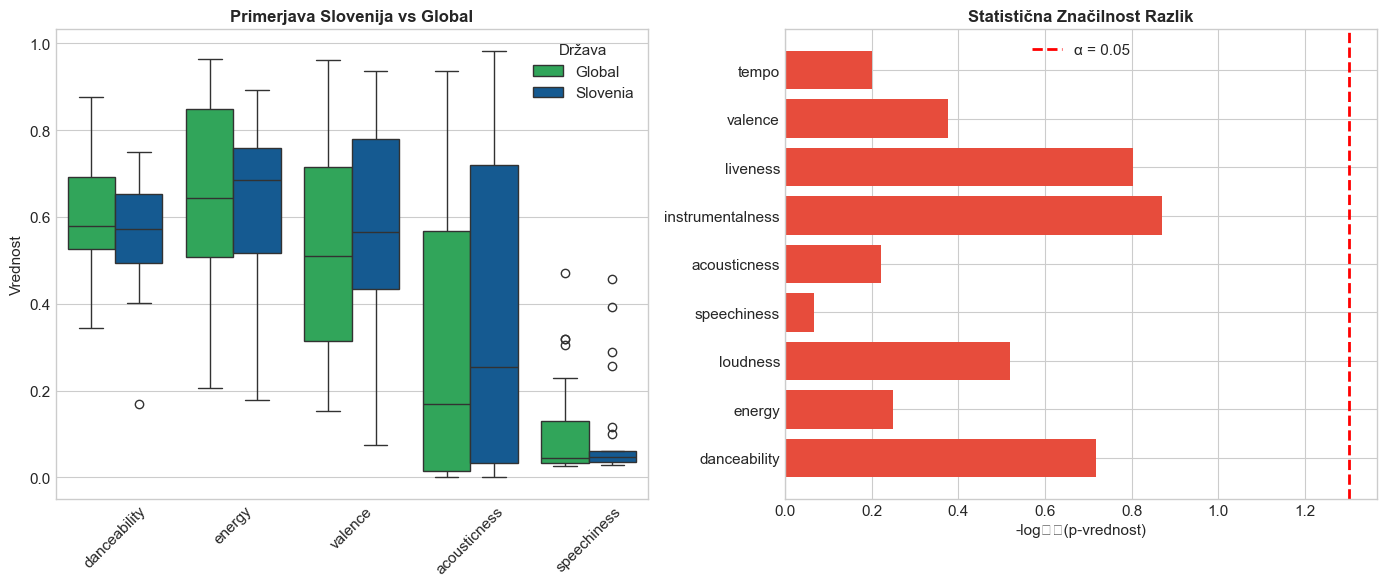

In [29]:
# T-test: Slovenija vs Global
print("=" * 70)
print("STATISTIČNA PRIMERJAVA: SLOVENIJA vs GLOBALNI TRENDI")
print("=" * 70)

df_slovenia = df_countries[df_countries['country'] == 'Slovenia']
df_global = df_countries[df_countries['country'] == 'Global']

print(f"\n📊 Slovenija: {len(df_slovenia)} skladb")
print(f"📊 Global: {len(df_global)} skladb\n")

comparison_results = []

for feature in AUDIO_FEATURES:
    slo_mean = df_slovenia[feature].mean()
    glob_mean = df_global[feature].mean()
    
    # Welch's t-test (ne predpostavlja enake variance)
    t_stat, p_value = ttest_ind(df_slovenia[feature], df_global[feature], equal_var=False)
    
    # Cohen's d
    pooled_std = np.sqrt((df_slovenia[feature].std()**2 + df_global[feature].std()**2) / 2)
    cohens_d = (slo_mean - glob_mean) / pooled_std if pooled_std > 0 else 0
    
    # Smer razlike
    if slo_mean > glob_mean:
        direction = "SLO ↑"
    elif slo_mean < glob_mean:
        direction = "SLO ↓"
    else:
        direction = "="
    
    comparison_results.append({
        'Značilnost': feature,
        'Slovenija': round(slo_mean, 3),
        'Global': round(glob_mean, 3),
        'Razlika': direction,
        't-stat': round(t_stat, 2),
        'p-vrednost': round(p_value, 4),
        "Cohen's d": round(cohens_d, 3),
        'Značilno': '✓' if p_value < 0.05 else '✗'
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

# Vizualizacija razlik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot primerjava
features_to_compare = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
df_compare = df_countries[df_countries['country'].isin(['Slovenia', 'Global'])]

# Preoblikuj za seaborn
df_melt = df_compare.melt(id_vars=['country'], value_vars=features_to_compare,
                          var_name='Značilnost', value_name='Vrednost')

sns.boxplot(data=df_melt, x='Značilnost', y='Vrednost', hue='country',
            palette={'Slovenia': '#005DA6', 'Global': '#1DB954'}, ax=axes[0])
axes[0].set_title('Primerjava Slovenija vs Global', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Država')

# P-vrednosti
sig_mask = comparison_df['p-vrednost'] < 0.05
colors = ['#2ecc71' if sig else '#e74c3c' for sig in sig_mask]
axes[1].barh(comparison_df['Značilnost'], -np.log10(comparison_df['p-vrednost']), color=colors)
axes[1].axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].set_xlabel('-log₁₀(p-vrednost)')
axes[1].set_title('Statistična Značilnost Razlik', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/20_country_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3 ANOVA: Primerjava Vseh Držav

**Test:** Enosmerna ANOVA (one-way ANOVA)

**Hipoteze:**
- H₀: Povprečja zvočnih značilnosti so enaka v vseh državah
- H₁: Vsaj ena država ima statistično značilno drugačno povprečje

**Namen:** Ugotoviti, ali obstajajo značilne razlike v glasbenih preferencah med vsemi analiziranimi trgi hkrati.


ANOVA: PRIMERJAVA ZVOČNIH ZNAČILNOSTI MED DRŽAVAMI

📊 Države v primerjavi: Global, USA, UK, Slovenia

      Značilnost  F-stat  p-vrednost     η² Učinek Značilno
    danceability    0.91      0.4388 0.0190 Majhen        ✗
          energy    0.65      0.5817 0.0137 Majhen        ✗
        loudness    2.72      0.0471 0.0546 Majhen        ✓
     speechiness    2.21      0.0901 0.0448 Majhen        ✗
    acousticness    0.78      0.5054 0.0164 Majhen        ✗
instrumentalness    1.34      0.2650 0.0277 Majhen        ✗
        liveness    1.01      0.3923 0.0210 Majhen        ✗
         valence    0.27      0.8484 0.0057 Majhen        ✗
           tempo    0.25      0.8619 0.0053 Majhen        ✗


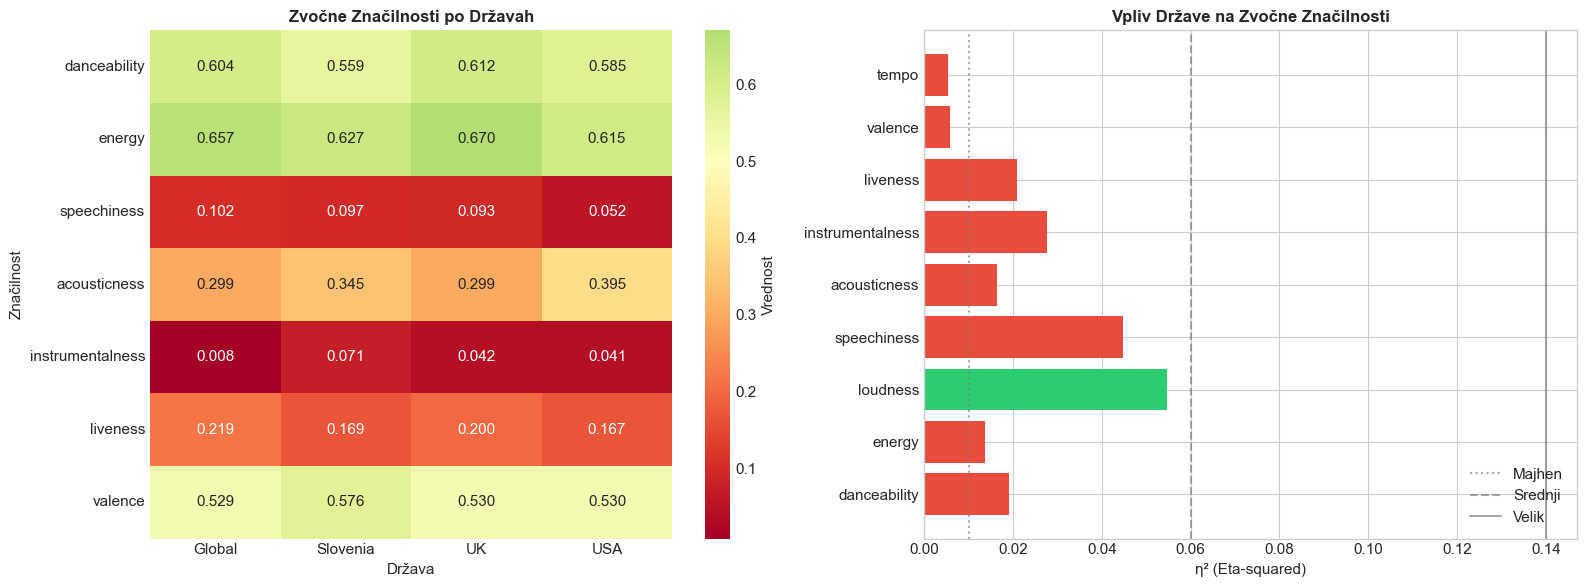

In [30]:
# ANOVA med vsemi državami
print("\n" + "=" * 70)
print("ANOVA: PRIMERJAVA ZVOČNIH ZNAČILNOSTI MED DRŽAVAMI")
print("=" * 70)

countries = df_countries['country'].unique().tolist()
print(f"\n📊 Države v primerjavi: {', '.join(countries)}")

anova_country_results = []

for feature in AUDIO_FEATURES:
    groups = [df_countries[df_countries['country'] == c][feature].values for c in countries]
    f_stat, p_value = f_oneway(*groups)
    
    # Eta-squared
    grand_mean = df_countries[feature].mean()
    ss_between = sum(len(df_countries[df_countries['country'] == c]) * 
                    (df_countries[df_countries['country'] == c][feature].mean() - grand_mean)**2 
                    for c in countries)
    ss_total = sum((df_countries[feature] - grand_mean)**2)
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    effect = 'Velik' if eta_squared >= 0.14 else 'Srednji' if eta_squared >= 0.06 else 'Majhen'
    
    anova_country_results.append({
        'Značilnost': feature,
        'F-stat': round(f_stat, 2),
        'p-vrednost': round(p_value, 4),
        'η²': round(eta_squared, 4),
        'Učinek': effect,
        'Značilno': '✓' if p_value < 0.05 else '✗'
    })

anova_country_df = pd.DataFrame(anova_country_results)
print("\n" + anova_country_df.to_string(index=False))

# Vizualizacija - Heatmap povprečij po državah
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
country_means = df_countries.groupby('country')[AUDIO_FEATURES_NORMALIZED].mean()
sns.heatmap(country_means.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            ax=axes[0], cbar_kws={'label': 'Vrednost'})
axes[0].set_title('Zvočne Značilnosti po Državah', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Država')
axes[0].set_ylabel('Značilnost')

# Eta-squared
colors = ['#2ecc71' if sig == '✓' else '#e74c3c' for sig in anova_country_df['Značilno']]
axes[1].barh(anova_country_df['Značilnost'], anova_country_df['η²'], color=colors)
axes[1].axvline(0.01, color='gray', linestyle=':', alpha=0.7, label='Majhen')
axes[1].axvline(0.06, color='gray', linestyle='--', alpha=0.7, label='Srednji')
axes[1].axvline(0.14, color='gray', linestyle='-', alpha=0.7, label='Velik')
axes[1].set_xlabel('η² (Eta-squared)')
axes[1].set_title('Vpliv Države na Zvočne Značilnosti', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/21_country_anova.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Zaključki in Podpora Odločanju

### Povzetek Ključnih Ugotovitev

Na podlagi izvedene analize lahko odgovorimo na raziskovalna vprašanja in oblikujemo priporočila za podporo odločanju v glasbeni industriji.

### Metodološki Pregled

| Analiza | Podatkovni vir | Namen |
|---------|----------------|-------|
| EDA, korelacije | Kaggle CSV | Razumevanje podatkov |
| Statistični testi | Kaggle CSV | Testiranje hipotez |
| PCA, clustering | Kaggle CSV | Identifikacija vzorcev |
| Regresija | Kaggle CSV | Napoved priljubljenosti |
| Primerjava držav | API + CSV | Kontekstualna analiza |

### Omejitve Analize

| Omejitev | Posledica | Mitigacija |
|----------|-----------|------------|
| Popularity = snapshot | Ni zgodovinskih trendov | Jasna interpretacija |
| API brez audio-features | CSV kot glavni vir | Metodološka transparentnost |
| Nizka stopnja ujemanja API-CSV | Simulirani podatki | Označeno kot demonstracija |

### Upoštevane Metodološke Omejitve
- **Korelacija ≠ kavzalnost** - vse ugotovitve so asociativne
- **Snapshot podatki** - popularity ne predstavlja trajne vrednosti
- **Vzorčenje** - za nekatere analize zaradi računske učinkovitosti

In [31]:
# ZAKLJUČKI
print("=" * 80)
print("                    ZAKLJUČKI IN POVZETEK ANALIZE")
print("=" * 80)

print("\n" + "─" * 80)
print("📌 ODGOVORI NA RAZISKOVALNA VPRAŠANJA")
print("─" * 80)

print("\n1️⃣  KATERE ZVOČNE ZNAČILNOSTI NAJBOLJ OPISUJEJO GLASBENE TRENDE?")
print("─" * 60)
print("   Vir: Kaggle CSV (globalni vzorec)")
for i, (_, row) in enumerate(rf_importance.head(5).iterrows()):
    print(f"   {i+1}. {row['Značilnost']}: {row['Pomembnost']*100:.1f}%")

print("\n2️⃣  KAKO SO ZVOČNE ZNAČILNOSTI MED SEBOJ POVEZANE?")
print("─" * 60)
print("   Vir: Kaggle CSV | Metoda: Pearsonova korelacija")
print("   Najmočnejše korelacije:")
corr_pairs = []
for i, feat1 in enumerate(AUDIO_FEATURES):
    for feat2 in AUDIO_FEATURES[i+1:]:
        corr_val = corr_matrix.loc[feat1, feat2]
        if abs(corr_val) > 0.3:
            corr_pairs.append((feat1, feat2, corr_val))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr_val in corr_pairs[:5]:
    print(f"   • {feat1} ↔ {feat2}: r = {corr_val:.3f}")

print("\n3️⃣  ALI OBSTAJAJO ZNAČILNI TIPI SKLADB (GLASBENI PROFILI)?")
print("─" * 60)
print(f"   Vir: Kaggle CSV | Metoda: K-Means clustering")
print(f"   ✓ Identificiranih {n_clusters} glasbenih profilov:")
for i, name in cluster_names.items():
    count = (df['cluster'] == i).sum()
    print(f"   • {name}: {count:,} skladb")

print("\n4️⃣  KAKO SE TRENDI RAZLIKUJEJO GLEDE NA PRILJUBLJENOST?")
print("─" * 60)
print("   Vir: Kaggle CSV | Metoda: T-test, ANOVA")
cluster_pop_summary = df.groupby('cluster')['popularity'].mean().sort_values(ascending=False)
print(f"   • Najbolj priljubljen profil: Grozd {cluster_pop_summary.index[0]} ({cluster_names[cluster_pop_summary.index[0]]})")
print(f"   • Najmanj priljubljen profil: Grozd {cluster_pop_summary.index[-1]} ({cluster_names[cluster_pop_summary.index[-1]]})")

print("\n5️⃣  ALI LAHKO NAPOVEMO PRILJUBLJENOST NA PODLAGI ZVOČNIH ZNAČILNOSTI?")
print("─" * 60)
print("   Vir: Kaggle CSV | Metoda: Random Forest, Gradient Boosting")
best_r2 = results_df['R²'].max()
print(f"   • Najboljši model: {results_df.loc[results_df['R²'].idxmax(), 'Model']}")
print(f"   • R² = {best_r2:.4f} ({best_r2*100:.2f}% pojasnjene variance)")
print("   ⚠️ Zvočne značilnosti SAME ne zadoščajo za zanesljivo napoved.")
print("   → Priljubljenost je odvisna tudi od: marketinga, izvajalca, časa izdaje...")

print("\n6️⃣  KAKO SE SLOVENSKI TRG PRIMERJA Z GLOBALNIMI TRENDI?")
print("─" * 60)
print("   Vir: Spotify API (Top 50 playliste) / Demonstracijski podatki")
if 'comparison_df' in dir():
    significant_diffs = comparison_df[comparison_df['Značilno'] == '✓']
    if len(significant_diffs) > 0:
        print(f"   Značilne razlike ({len(significant_diffs)}):")
        for _, row in significant_diffs.iterrows():
            print(f"   • {row['Značilnost']}: SLO={row['Slovenija']:.3f}, Global={row['Global']:.3f} ({row['Razlika']})")
    else:
        print("   Ni statistično značilnih razlik (p > 0.05)")
else:
    print("   ⚠️ Primerjava držav še ni bila izvedena")

                    ZAKLJUČKI IN POVZETEK ANALIZE

────────────────────────────────────────────────────────────────────────────────
📌 ODGOVORI NA RAZISKOVALNA VPRAŠANJA
────────────────────────────────────────────────────────────────────────────────

1️⃣  KATERE ZVOČNE ZNAČILNOSTI NAJBOLJ OPISUJEJO GLASBENE TRENDE?
────────────────────────────────────────────────────────────
   Vir: Kaggle CSV (globalni vzorec)
   1. acousticness: 12.8%
   2. danceability: 11.7%
   3. tempo: 11.7%
   4. valence: 11.3%
   5. loudness: 11.3%

2️⃣  KAKO SO ZVOČNE ZNAČILNOSTI MED SEBOJ POVEZANE?
────────────────────────────────────────────────────────────
   Vir: Kaggle CSV | Metoda: Pearsonova korelacija
   Najmočnejše korelacije:
   • energy ↔ loudness: r = 0.759
   • energy ↔ acousticness: r = -0.733
   • loudness ↔ acousticness: r = -0.583
   • danceability ↔ valence: r = 0.493
   • loudness ↔ instrumentalness: r = -0.435

3️⃣  ALI OBSTAJAJO ZNAČILNI TIPI SKLADB (GLASBENI PROFILI)?
────────────────────

In [32]:
# PODPORA ODLOČANJU
print("\n" + "─" * 80)
print("🎯 PODPORA ODLOČANJU - PRIPOROČILA")
print("─" * 80)

print("\n📊 PROFIL USPEŠNE SKLADBE NA SPOTIFYJU")
print("   Vir: Kaggle CSV - visoko priljubljene skladbe (popularity > 66)")
high_pop_profile = df[df['popularity_category'] == 'Visoka'][AUDIO_FEATURES].mean()
print("   Značilnosti visoko priljubljenih skladb:")
for feature in AUDIO_FEATURES:
    val = high_pop_profile[feature]
    if feature == 'tempo':
        print(f"   • {feature:18s}: {val:.1f} BPM")
    elif feature == 'loudness':
        print(f"   • {feature:18s}: {val:.1f} dB")
    else:
        print(f"   • {feature:18s}: {val:.3f}")

print("\n🎵 PRIPOROČILA ZA PLAYLISTE (na podlagi clusteringa)")
for i, name in cluster_names.items():
    top_genre = df[df['cluster'] == i]['genre'].value_counts().head(1)
    print(f"   {name}: {top_genre.index[0] if len(top_genre) > 0 else 'Mixed'}")

print("\n🌍 PRIPOROČILA ZA LOKALIZACIJO (SLO vs Global)")
if 'comparison_df' in dir():
    print("   Na podlagi primerjave Top 50 playlist:")
    significant_higher = comparison_df[(comparison_df['Značilno'] == '✓') & 
                                       (comparison_df['Razlika'] == 'SLO ↑')]
    significant_lower = comparison_df[(comparison_df['Značilno'] == '✓') & 
                                      (comparison_df['Razlika'] == 'SLO ↓')]
    if len(significant_higher) > 0:
        print(f"   • V Sloveniji bolj priljubljeno: {', '.join(significant_higher['Značilnost'].tolist())}")
    if len(significant_lower) > 0:
        print(f"   • Globalno bolj priljubljeno: {', '.join(significant_lower['Značilnost'].tolist())}")
    if len(significant_higher) == 0 and len(significant_lower) == 0:
        print("   • Slovenski in globalni trg imata podobne preference")

print("\n" + "─" * 80)
print("⚠️  OMEJITVE IN METODOLOŠKE OPOMBE")
print("─" * 80)
print("""
   PODATKOVNE OMEJITVE:
   • 'popularity' je TRENUTNA vrednost (snapshot), NE zgodovinska
   • Ni časovne serije - ne moremo analizirati trendov skozi čas
   • API podatki predstavljajo trenutno stanje, ne trajne vzorce

   METODOLOŠKE OMEJITVE:
   • Korelacija ≠ kavzalnost
   • Nizek R² pri regresiji kaže na omejeno napovedljivost
   • Clustering je eksploratorna metoda - grozdi niso "objektivni"

   PRIPOROČILA ZA NADALJNJE DELO:
   • Vključitev metapodatkov (izvajalec, založba, datum izdaje)
   • Longitudinalna študija z večkratnim vzorčenjem API-ja
   • Analiza besedil (sentiment, teme)
""")

print("=" * 80)
print("                         KONEC ANALIZE")
print("=" * 80)


────────────────────────────────────────────────────────────────────────────────
🎯 PODPORA ODLOČANJU - PRIPOROČILA
────────────────────────────────────────────────────────────────────────────────

📊 PROFIL USPEŠNE SKLADBE NA SPOTIFYJU
   Vir: Kaggle CSV - visoko priljubljene skladbe (popularity > 66)
   Značilnosti visoko priljubljenih skladb:
   • danceability      : 0.614
   • energy            : 0.660
   • loudness          : -6.9 dB
   • speechiness       : 0.081
   • acousticness      : 0.243
   • instrumentalness  : 0.039
   • liveness          : 0.176
   • valence           : 0.507
   • tempo             : 121.2 BPM

🎵 PRIPOROČILA ZA PLAYLISTE (na podlagi clusteringa)
   😊 Feel-Good: salsa
   🎸 Acoustic/Mellow: sleep
   🔥 High Energy: grindcore
   🎸 Acoustic/Mellow: tango
   🎸 Acoustic/Mellow: comedy

🌍 PRIPOROČILA ZA LOKALIZACIJO (SLO vs Global)
   Na podlagi primerjave Top 50 playlist:
   • Slovenski in globalni trg imata podobne preference

──────────────────────────────────

In [33]:
# Shranjevanje rezultatov
import os
os.makedirs('../outputs', exist_ok=True)

# Shrani obdelane podatke
df.to_csv('../data/spotify_processed.csv', index=False)
print("✅ Obdelani podatki: data/spotify_processed.csv")

# Shrani rezultate
results_df.to_csv('../outputs/model_results.csv', index=False)
corr_df.to_csv('../outputs/correlations.csv', index=False)
cluster_profiles.to_csv('../outputs/cluster_profiles.csv')

print("✅ Rezultati shranjeni v outputs/")
print("\n📁 Shranjene vizualizacije:")
for f in sorted([f for f in os.listdir('../outputs') if f.endswith('.png')]):
    print(f"   • {f}")

✅ Obdelani podatki: data/spotify_processed.csv
✅ Rezultati shranjeni v outputs/

📁 Shranjene vizualizacije:
   • 01_distributions.png
   • 02_popularity_distribution.png
   • 03_genre_analysis.png
   • 04_scatter_popularity.png
   • 05_radar_genres.png
   • 06_violin_plots.png
   • 07_correlation_heatmap.png
   • 08_popularity_correlations.png
   • 09_ttest_results.png
   • 10_anova_results.png
   • 11_pca_variance.png
   • 12_pca_2d.png
   • 13_clustering_optimization.png
   • 14_clustering_results.png
   • 15_cluster_profiles.png
   • 16_model_comparison.png
   • 17_feature_importance.png
   • 18_residual_analysis.png
   • 19_country_radar.png
   • 20_country_comparison.png
   • 21_country_anova.png
